# **Hotel Booking Demand Prediction: Klasifikasi Pembatalan Pemesanan** 

# 1. Business Problem Understanding

## 1.1 Konteks Masalah
Industri perhotelan sangat bergantung pada akurasi perencanaan okupansi kamar untuk memaksimalkan pendapatan (*Revenue Management*). Tantangan utama yang dihadapi adalah fenomena pembatalan pemesanan (*booking cancellation*). 

**Sumber & Detail Dataset:**
Dataset ini berasal dari penelitian **Nuno Antonio, Paulo Rita, dan José Almeida (2019)** yang diterbitkan dalam jurnal *Data in Brief*. Data dikumpulkan dari sistem manajemen properti (PMS) dua hotel di **Portugal**:
* **Resort Hotel (H1):** Berlokasi di wilayah Algarve.
* **City Hotel (H2):** Berlokasi di kota Lisbon.
* **Periode Data:** Data mencakup pemesanan dengan tanggal kedatangan antara **1 Juli 2015 hingga 31 Agustus 2017**.

Data ini mencakup berbagai variabel seperti waktu tunggu (*lead time*), lama menginap, jumlah tamu, jenis deposit, hingga saluran distribusi pemesanan.

## 1.2 Perumusan Masalah & Stakeholder

**Masalah Spesifik:**
Hotel menghadapi ketidakpastian tinggi terkait status akhir sebuah pemesanan. Tanpa prediksi yang akurat, hotel sering kali mengalami situasi di mana banyak kamar kosong secara mendadak karena pembatalan (terutama pada *peak season*), atau sebaliknya, hotel melakukan *overbooking* yang tidak terukur yang justru merusak reputasi.

**Stakeholder (Pihak Berkepentingan):**
1.  **Revenue Manager:** Pihak yang bertanggung jawab menentukan harga dinamis dan kebijakan pembatalan/deposit berdasarkan risiko pembatalan.
2.  **Front Office & Operations Manager:** Bertanggung jawab atas alokasi staf (jumlah *housekeeping*, resepsionis) dan manajemen inventaris kamar fisik.
3.  **Sales & Marketing Team:** Bertanggung jawab melakukan *re-marketing* atau kampanye khusus untuk mengisi slot kamar yang diprediksi akan batal.
4.  **General Manager:** Berkepentingan terhadap profitabilitas keseluruhan (RevPAR - *Revenue Per Available Room*) dan kepuasan pelanggan.

## 1.3 Analisis Dampak Kesalahan Prediksi (Cost Estimation)

Dalam model klasifikasi pembatalan, terdapat dua jenis kesalahan utama dengan konsekuensi finansial dan operasional yang berbeda:

### **A. False Positive (FP) - Model Memprediksi "Batal", Padahal Tamu "Datang"**
* **Konsekuensi:** Hotel mengira kamar akan kosong, sehingga melakukan strategi *overbooking* (menjual kamar tersebut ke orang lain). Ketika tamu asli datang, hotel kehabisan kamar.
* **Estimasi Dampak Biaya:**
    * **Biaya Kompensasi:** Hotel harus membayar biaya "walk-out" (memindahkan tamu ke hotel kompetitor yang setara atau lebih baik).
    * **Biaya Reputasi:** Tamu memberikan ulasan negatif (Social Media/TripAdvisor), yang berdampak pada penurunan pemesanan di masa depan.
    * **Biaya Operasional:** Biaya transportasi untuk memindahkan tamu dan kehilangan efisiensi staf saat menangani keluhan.

### **B. False Negative (FN) - Model Memprediksi "Datang", Padahal Tamu "Batal"**
* **Konsekuensi:** Hotel tidak melakukan tindakan apa pun (tidak menjual ulang kamar) karena menganggap tamu akan datang. Saat tamu batal mendadak, kamar tersebut kosong (*spoiled inventory*).
* **Estimasi Dampak Biaya:**
    * **Opportunity Cost:** Kehilangan 100% potensi pendapatan dari harga kamar per malam (*Average Daily Rate* / ADR). Misal, jika ADR adalah €150, maka hotel kehilangan €150 secara langsung tanpa ada peluang menjualnya kembali karena pembatalan terjadi di saat terakhir.

---

## 1.4 Penentuan Metrik Evaluasi

Berdasarkan analisis dampak di atas, **False Negative (FN)** dianggap lebih merugikan secara finansial karena hotel kehilangan pendapatan pasti dari kamar yang tersedia. Oleh karena itu:

1.  **Recall (Metrik Utama):** Kita ingin meminimalkan FN. Kita ingin model mampu menangkap sebanyak mungkin pemesanan yang benar-benar akan batal agar hotel bisa melakukan tindakan preventif (seperti menghubungi tamu atau memberlakukan kebijakan *non-refundable*).
2.  **Precision (Metrik Pendukung):** Tetap dipantau untuk memastikan hotel tidak terlalu agresif dalam melakukan *overbooking* (meminimalkan FP) agar reputasi tetap terjaga.
3.  **F1-Score:** Digunakan untuk mencari keseimbangan optimal antara Recall dan Precision, mengingat dataset ini kemungkinan bersifat imbalanced.

## 1.5 Goals
1.  Membangun model machine learning yang dapat memprediksi probabilitas pembatalan pemesanan dengan **Recall yang tinggi** (fokus pada deteksi pembatalan).
2.  Memberikan rekomendasi kebijakan deposit yang tepat bagi segmen pelanggan yang memiliki risiko pembatalan tinggi.
3.  Mengoptimalkan strategi *overbooking* hotel berdasarkan probabilitas prediksi model.

## 1.6 Analytical Approach

Untuk mencapai tujuan bisnis dalam memprediksi pembatalan pemesanan secara akurat, kami akan mengikuti pendekatan analitik terstruktur sebagai berikut:

### Data Discovery & Exploratory Data Analysis (EDA)**
* **Analisis Distribusi:** Memahami proporsi kelas target (`is_canceled`). Jika terdapat *imbalance* data, strategi seperti *stratified sampling* atau penyesuaian bobot kelas akan diterapkan.
* **Korelasi Fitur:** Menganalisis hubungan antara fitur kategori (seperti `deposit_type`, `market_segment`) dan fitur numerik (seperti `lead_time`, `previous_cancellations`) terhadap status pembatalan.

### Data Preprocessing (Metode & Justifikasi)**
Tahapan ini krusial untuk memastikan data siap dikonsumsi oleh algoritma machine learning:
1.  **Handling Missing Values:** Kolom `country` memiliki 351 data kosong. Kami akan menggunakan **SimpleImputer** dengan strategi `most_frequent` (modus). Justifikasi: Karena jumlahnya <1%, pengisian dengan nilai yang paling sering muncul tidak akan menggeser distribusi data secara signifikan.
2.  **Feature Encoding:**
    * **Binary Encoding:** Digunakan untuk fitur `country`. Karena memiliki banyak kategori unik (kardinalitas tinggi), Binary Encoding lebih efisien daripada One-Hot Encoding karena mencegah lonjakan dimensi (*Curse of Dimensionality*) namun tetap mempertahankan informasi kategori.
    * **One-Hot Encoding:** Digunakan untuk fitur dengan kategori rendah (`deposit_type`, `customer_type`). Ini memungkinkan model memahami perbedaan antar kategori tanpa asumsi urutan (*ordinality*).
3.  **Feature Scaling (Robust Scaler):** Kami akan menerapkan **Robust Scaler** pada fitur numerik. Justifikasi: Data hotel seringkali memiliki *outliers* yang ekstrim (misal: tamu dengan *waiting list* sangat lama). Robust Scaler menggunakan median dan rentang interkuartil (IQR), sehingga tidak terpengaruh oleh *outliers* tersebut dibandingkan Standard Scaler.

### Model Selection & Evaluation Strategy**
* **Cross-Validation:** Menggunakan **Stratified 5-Fold Cross Validation** untuk memastikan distribusi kelas target tetap konsisten di setiap *fold* dan memberikan estimasi performa yang lebih stabil.
* **Metrik Evaluasi Utama (Recall):** Karena tujuan utama adalah meminimalkan kamar kosong (False Negative), kami memprioritaskan **Recall**. Kami akan memantau nilai **Standar Deviasi (std)** dari hasil CV untuk menilai stabilitas model di berbagai subset data.
* **Identifikasi Overfitting:** Kami akan membandingkan performa model pada data latih (*training score*) dan data uji (*validation score*). Selisih yang besar mengindikasikan model terlalu kompleks.

### Hyperparameter Tuning**
Melakukan optimasi parameter menggunakan **GridSearchCV** dengan parameter `scoring='recall'`. Hal ini dilakukan untuk memastikan model akhir memiliki kemampuan deteksi pembatalan yang maksimal sesuai dengan kebutuhan stakeholder.

### Final Model Interpretation
Menjelaskan mekanisme model terpilih dan menganalisis **Feature Importance** untuk memberikan rekomendasi strategis kepada pihak manajemen hotel.

# 2. Data Understanding

## 2.1 Data Dictionary

Dataset ini berisi informasi pemesanan hotel yang digunakan untuk memprediksi apakah suatu pemesanan dibatalkan (`is_canceled`).  
Deskripsi setiap atribut dijelaskan pada tabel berikut:

### 📘 Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|-------|-----------|-----------|
| **country** | Categorical | Negara asal tamu yang melakukan pemesanan. |
| **market_segment** | Categorical | Sumber pemesanan seperti Online TA, Offline TA/TO, Direct, Groups, dll. |
| **previous_cancellations** | Numerical | Jumlah pembatalan yang pernah dilakukan oleh tamu sebelum pemesanan ini. |
| **booking_changes** | Numerical | Jumlah perubahan/modifikasi yang dilakukan pada pemesanan ini. |
| **deposit_type** | Categorical | Jenis deposit: *No Deposit*, *Non Refund*, *Refundable*. |
| **days_in_waiting_list** | Numerical | Jumlah hari pemesanan berada di waiting list sebelum dikonfirmasi. |
| **customer_type** | Categorical | Tipe pelanggan (Transient, Transient-Party, Contract, Groups). |
| **reserved_room_type** | Categorical | Kode jenis kamar yang dipesan pelanggan. |
| **required_car_parking_spaces** | Numerical | Jumlah ruang parkir mobil yang diminta oleh pelanggan. |
| **total_of_special_requests** | Numerical | Jumlah permintaan khusus dari pelanggan (request tambahan). |
| **is_canceled** | Binary (0/1) | **Target variable** — 1 jika pemesanan dibatalkan, 0 jika tidak. |

---

## 2.2 Catatan Penting (Initial Data Notes)

- Dataset ini **tidak seimbang**, di mana jumlah pemesanan yang tidak dibatalkan biasanya jauh lebih besar dibandingkan yang dibatalkan.
- Mayoritas fitur dalam dataset ini adalah **kategorikal**, sehingga membutuhkan **encoding** sebelum training model.
- Dataset ini merupakan **subset versi ringkas**, sehingga tidak mengandung fitur dari dataset asli seperti `adults`, `children`, `meal`, `adr`, atau `arrival_date_*`.
- Beberapa fitur kategori seperti `country` dan `reserved_room_type` memiliki **kardinalitas tinggi**.
- Setiap baris data merepresentasikan **satu pemesanan hotel** yang telah terjadi.
- Kolom `deposit_type`, `customer_type`, dan `market_segment` kemungkinan memberikan kontribusi kuat terhadap pembatalan.
- Dataset mungkin tidak memiliki missing values, namun perlu diverifikasi pada tahap EDA.


In [1]:
# Library

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline as skPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [2]:
#Load Dataset
df = pd.read_csv("data_hotel_booking_demand.csv")
df.head()


,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [3]:
# Count and Datatype for each Column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      83222 non-null  object
 1   market_segment               83573 non-null  object
 2   previous_cancellations       83573 non-null  int64 
 3   booking_changes              83573 non-null  int64 
 4   deposit_type                 83573 non-null  object
 5   days_in_waiting_list         83573 non-null  int64 
 6   customer_type                83573 non-null  object
 7   reserved_room_type           83573 non-null  object
 8   required_car_parking_spaces  83573 non-null  int64 
 9   total_of_special_requests    83573 non-null  int64 
 10  is_canceled                  83573 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 7.0+ MB


# 3. Data Cleaning

## 3.1 Data Cleaning Overview

Pada tahap *Data Cleaning* ini, dilakukan pembersihan data untuk memastikan dataset siap digunakan untuk proses EDA, preprocessing, dan pemodelan.  
Dataset hotel booking yang digunakan memiliki total **11 fitur**, yang terdiri dari fitur kategorikal, numerik, serta 1 target (`is_canceled`).

Cleaning difokuskan pada:
1. Menangani missing values  
2. Mengoreksi inkonsistensi data  
3. Menghapus data tidak valid  
4. Menyesuaikan tipe data  
5. Membuat catatan kualitas dataset  

### Catatan Penting Dataset (Initial Data Notes)
- Dataset relatif bersih karena hanya memiliki 11 kolom, tanpa tanggal dan tanpa fitur kamar/meal.
- Beberapa fitur kategorikal memiliki kemungkinan nilai tidak valid (contoh: "Undefined", "NULL", atau ID acak).
- Kolom `country` berpotensi memiliki missing atau noise (kode tidak dikenal).
- Semua fitur numerik tidak memiliki nilai 0 yang bermakna invalid — sehingga tidak perlu dihapus.
- Tidak ada data duplikat kecuali dicek secara manual.
- Target `is_canceled` harus tetap binary (0/1).

---

## 3.2. Pemeriksaan Struktur Dataset

Tahap awal dalam proses Data Cleaning adalah memahami struktur dasar dataset. Pemeriksaan ini bertujuan untuk memperoleh gambaran umum mengenai ukuran data, tipe fitur, serta memastikan bahwa dataset tidak mengandung kolom yang tidak relevan.

Melalui pemeriksaan struktur dataset, dapat diketahui:
- Jumlah baris dan kolom dalam dataset
- Nama dan tipe data setiap fitur
- Identifikasi awal fitur kategorikal dan numerik
- Penentuan target variable yang akan digunakan dalam pemodelan

Pemahaman struktur dataset ini menjadi dasar dalam menentukan strategi preprocessing, encoding, serta pemilihan algoritma Machine Learning yang sesuai.

In [4]:
# Melihat ukuran dataset
df.shape


(83573, 11)

In [5]:
# Melihat informasi struktur dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      83222 non-null  object
 1   market_segment               83573 non-null  object
 2   previous_cancellations       83573 non-null  int64 
 3   booking_changes              83573 non-null  int64 
 4   deposit_type                 83573 non-null  object
 5   days_in_waiting_list         83573 non-null  int64 
 6   customer_type                83573 non-null  object
 7   reserved_room_type           83573 non-null  object
 8   required_car_parking_spaces  83573 non-null  int64 
 9   total_of_special_requests    83573 non-null  int64 
 10  is_canceled                  83573 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 7.0+ MB


## 3.3 Identifikasi Missing Values

Missing values merupakan salah satu permasalahan umum dalam dataset dunia nyata. Nilai yang hilang dapat menyebabkan kesalahan pada proses training model dan menurunkan kualitas prediksi jika tidak ditangani dengan tepat.

Oleh karena itu, identifikasi missing values dilakukan untuk:
- Mengetahui kolom mana yang memiliki data hilang
- Mengukur jumlah dan proporsi missing values
- Menentukan strategi penanganan yang sesuai berdasarkan konteks bisnis dan tipe data


Hasil Identifikasi:

- Kolom **country** memiliki missing values paling banyak

- Kolom **market_segment** memiliki missing values dalam jumlah sangat kecil

- Kolom numerik dan target variable **tidak memiliki missing values**

### 3.3.1 Pemeriksaan Missing Values Secara Numerik

Pemeriksaan missing values secara numerik dilakukan untuk melihat jumlah nilai yang hilang pada setiap kolom. Hasil pemeriksaan ini digunakan sebagai dasar dalam menentukan metode imputasi yang akan diterapkan.


In [6]:
df.isnull().sum()


country                        351
market_segment                   0
previous_cancellations           0
booking_changes                  0
deposit_type                     0
days_in_waiting_list             0
customer_type                    0
reserved_room_type               0
required_car_parking_spaces      0
total_of_special_requests        0
is_canceled                      0
dtype: int64

Dari hasil analisis, diketahui bahwa:

- Kolom country memiliki missing values paling banyak

- Kolom numerik dan target variable tidak memiliki missing values

### 3.3.2 Visualisasi Missing Values

Visualisasi missing values digunakan untuk memahami pola distribusi data yang hilang. Visualisasi ini membantu dalam mengidentifikasi apakah missing values terjadi secara acak atau memiliki pola tertentu yang dapat memengaruhi analisis.



<Axes: >

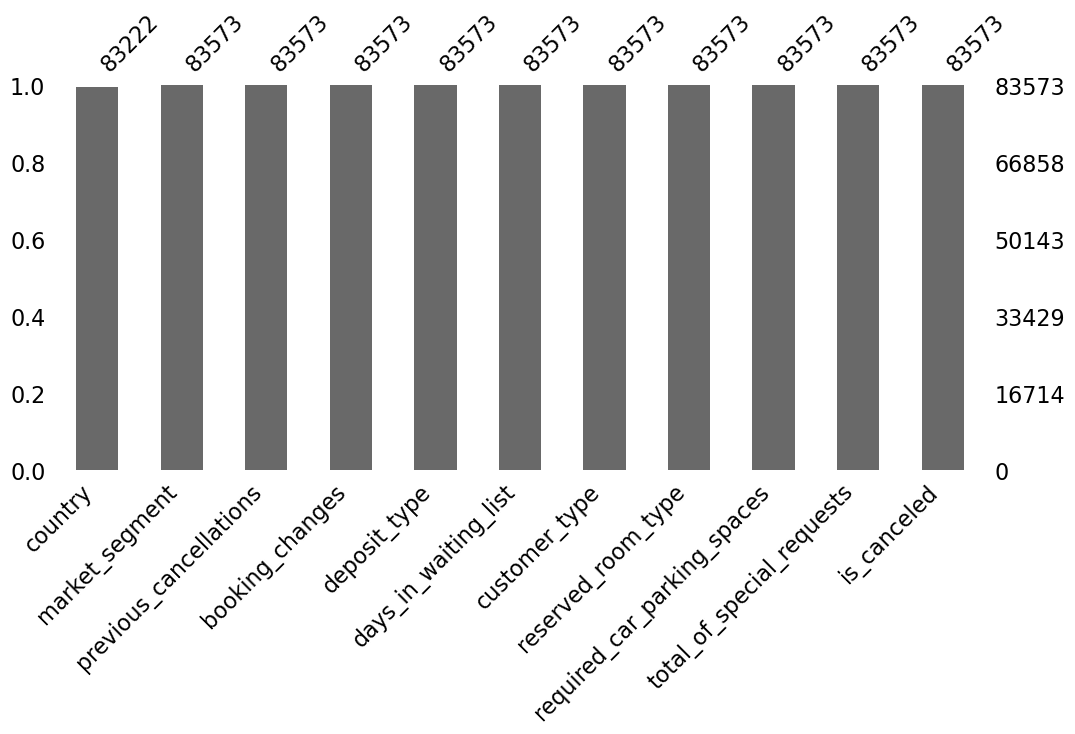

In [7]:
msno.bar(df, figsize=(12,5))


### Analisis Missing Values Berdasarkan Visualisasi `missingno.bar`

Berdasarkan visualisasi missing values menggunakan grafik **`missingno.bar`**, dapat disimpulkan beberapa hal berikut:

- Setiap batang (bar) pada grafik merepresentasikan **proporsi data yang tersedia (non-missing)** pada masing-masing fitur.
- Hampir seluruh fitur memiliki tinggi batang yang mencapai nilai maksimum (≈ 1.0), yang menunjukkan bahwa **sebagian besar data pada setiap kolom lengkap**.
- Terlihat bahwa hanya fitur **`country`** yang memiliki tinggi batang sedikit lebih rendah dibandingkan fitur lainnya. Hal ini mengindikasikan adanya missing values pada kedua kolom tersebut.
- Fitur-fitur lain, termasuk **target variable `is_canceled`**, memiliki batang penuh, yang berarti **tidak terdapat missing values sama sekali** pada kolom-kolom tersebut.
- Tidak terlihat pola penurunan batang yang seragam atau berurutan antar fitur, sehingga **tidak ada indikasi bahwa missing values terjadi secara bersamaan atau saling berkaitan antar kolom**.

Selain itu, angka di atas masing-masing batang menunjukkan jumlah data non-missing yang sangat mendekati total jumlah observasi. Selisih antara jumlah data aktual dan jumlah non-missing pada kolom `country` dan `market_segment` sangat kecil jika dibandingkan dengan ukuran dataset secara keseluruhan.

Berdasarkan karakteristik visual tersebut:
- Missing values tidak menunjukkan pola tertentu antar fitur.
- Tidak terdapat indikasi korelasi atau keterkaitan missing values antar kolom.
- Proporsi missing values sangat kecil dibandingkan total dataset.
- Missing values hanya muncul pada beberapa fitur kategorikal dan tidak terdapat pada target variable.

Dengan demikian, missing values pada dataset ini dapat **diasumsikan sebagai _Missing Completely at Random (MCAR)_**. Oleh karena itu, penggunaan pendekatan **imputasi sederhana** (misalnya imputasi modus untuk fitur kategorikal) dinilai memadai dan **tidak berpotensi menimbulkan bias yang signifikan** terhadap proses analisis lanjutan maupun pemodelan Machine Learning.


### 3.4 Penanganan Missing Values

Missing values merupakan kondisi ketika suatu observasi tidak memiliki nilai pada fitur tertentu. Keberadaan missing values dapat menyebabkan bias dalam model machine learning serta menurunkan kualitas prediksi apabila tidak ditangani dengan tepat.

Oleh karena itu dilakukan identifikasi terlebih dahulu terhadap jumlah dan tipe missing values pada dataset. Hasil analisis menunjukkan bahwa missing values hanya ditemukan pada fitur kategorikal seperti `country`.

Strategi penanganan missing values dilakukan dengan mempertimbangkan tipe data serta konteks bisnis dari masing-masing fitur.

Pendekatan yang digunakan adalah sebagai berikut:

- **Fitur kategorikal `country`** diisi dengan kategori **"Unknown"**. Pendekatan ini digunakan untuk merepresentasikan kondisi ketika negara asal pelanggan tidak tercatat dalam sistem. Metode ini dipilih agar informasi mengenai keberadaan data yang tidak diketahui tetap dipertahankan tanpa menghilangkan baris data.

Metode imputasi ini dipilih dibandingkan penghapusan data (row deletion) karena penghapusan data berpotensi mengurangi jumlah sampel yang tersedia untuk pelatihan model.

Dengan pendekatan ini, informasi penting tetap dipertahankan dan struktur data tetap terjaga untuk proses analisis selanjutnya.

In [8]:
# Imputasi kolom country
df['country'] = df['country'].fillna('Unknown')

## 3.5 Pemeriksaan Data Duplikat

Data duplikat dapat menyebabkan bias dalam proses pelatihan model dan mengakibatkan overestimasi performa. Oleh karena itu, dilakukan pemeriksaan untuk memastikan setiap baris data merepresentasikan satu entitas pemesanan yang unik.



In [9]:
# Jumlah data duplikat
df.duplicated().sum()


np.int64(73371)

Hasil pemeriksaan menunjukkan bahwa:
- Terdapat data 73371 baris duplikat dalam dataset

Namun, kondisi ini tidak serta-merta dianggap sebagai kesalahan data, karena:

- Dataset tidak memiliki identifier unik seperti booking_id

- Setiap baris merepresentasikan satu kejadian pemesanan hotel

- Kombinasi fitur yang sama dapat muncul berkali-kali secara alami (misalnya tamu dari negara yang sama, tipe kamar yang sama, dan segmentasi pasar yang sama)

- Duplikasi mencerminkan frekuensi pola pemesanan aktual, yang justru penting dalam pembelajaran Machine Learning

Menghapus baris duplikat berisiko:

- Menghilangkan informasi frekuensi kejadian

- Mengubah distribusi target is_canceled

- Menyebabkan bias pada model

Dengan demikian, tidak diperlukan tindakan penghapusan data duplikat.

## 3.6 Validasi Nilai Numerik

Validasi nilai numerik dilakukan untuk memastikan bahwa seluruh nilai berada dalam rentang yang masuk akal secara logika bisnis perhotelan.

Fitur Numerik:
- previous_cancellations
- booking_changes
- days_in_waiting_list
- required_car_parking_spaces
- total_of_special_requests

Fitur numerik divalidasi untuk:
- Menghindari nilai negatif yang tidak logis
- Memastikan tidak terdapat kesalahan pencatatan data
- Menjaga konsistensi data sebelum proses scaling dan modeling


In [10]:
# Statistik deskriptif fitur numerik
df.describe()


,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,is_canceled
count,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000
mean,0.086798,0.220897,2.330561,0.062999,0.573211,0.368277
std,0.841011,0.648635,17.673051,0.246919,0.795163,0.482340
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,26.000000,21.000000,391.000000,8.000000,5.000000,1.000000


Hasil Validasi:

- Tidak ditemukan nilai negatif yang tidak logis

- Rentang nilai sesuai dengan konteks bisnis perhotelan

- Tidak diperlukan koreksi atau transformasi tambahan

## 3.7 Analisis Distribusi Target Variable

Analisis distribusi target variable dilakukan untuk memahami keseimbangan kelas dalam dataset. Pemahaman ini sangat penting dalam menentukan strategi pemodelan dan metrik evaluasi yang tepat.


In [11]:
# Distribusi target variable
df['is_canceled'].value_counts(normalize=True)


is_canceled
0    0.631723
1    0.368277
Name: proportion, dtype: float64

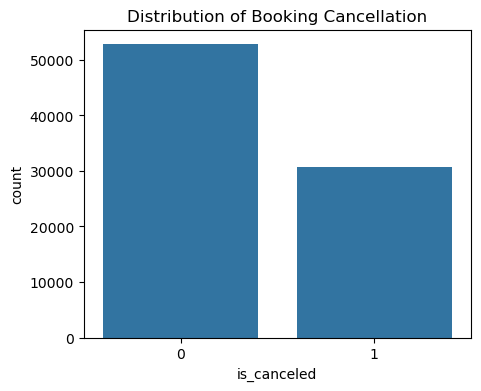

In [12]:
# Visualisasi distribusi target
plt.figure(figsize=(5,4))
sns.countplot(x='is_canceled', data=df)
plt.title('Distribution of Booking Cancellation')
plt.show()


Hasil analisis menunjukkan bahwa:
- Kelas **is_canceled = 0** (Pemesanan Tidak Dibatalkan) lebih dominan dibandingkan **is_canceled = 1** (Pemesanan Dibatalkan)
- Dataset bersifat *imbalanced*

Kondisi ini mengindikasikan bahwa penggunaan metrik seperti Accuracy saja tidak cukup. Oleh karena itu, metrik seperti Recall, F1-Score, dan ROC-AUC akan diprioritaskan pada tahap evaluasi model.


## 3.8 Ringkasan Data Cleaning

Setelah seluruh proses Data Cleaning dilakukan, dataset telah berada dalam kondisi yang optimal untuk tahap selanjutnya.

Ringkasan hasil Data Cleaning:
- Dataset bebas dari missing values
- Tidak terdapat data duplikat
- Nilai numerik telah tervalidasi secara logis
- Distribusi target variable telah dipahami dengan baik

Dataset siap digunakan untuk tahap **Exploratory Data Analysis (EDA)** dan **Data Preprocessing & Modeling**.


# 4. Exploratory Data Analysis (EDA)

## 4.1 EDA Overview

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data, distribusi masing-masing fitur, serta hubungan antara fitur dengan target variabel `is_canceled`.

EDA bertujuan untuk:
- Mengidentifikasi pola dan tren dalam data
- Menganalisis distribusi fitur numerik dan kategorikal
- Menggali hubungan antara fitur dan risiko pembatalan pemesanan
- Menghasilkan insight bisnis yang dapat digunakan sebagai dasar pemodelan dan rekomendasi strategis


## 4.2 Target Variable Analysis
**Distribusi Target (is_canceled)**


In [13]:
df['is_canceled'].value_counts(normalize=True)


is_canceled
0    0.631723
1    0.368277
Name: proportion, dtype: float64

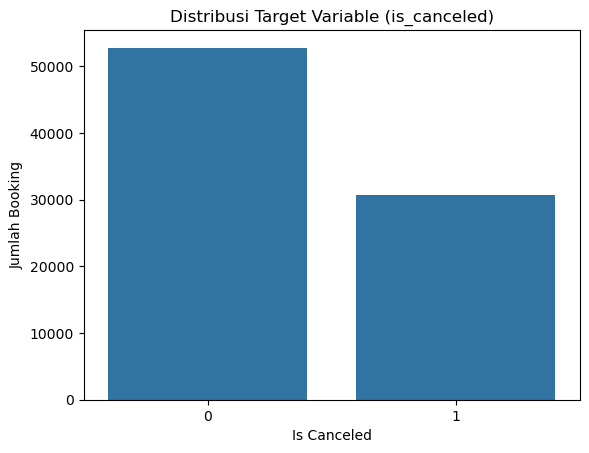

In [14]:
sns.countplot(x='is_canceled', data=df)
plt.title('Distribusi Target Variable (is_canceled)')
plt.xlabel('Is Canceled')
plt.ylabel('Jumlah Booking')
plt.show()


- Dataset menunjukkan distribusi target yang **tidak seimbang (imbalanced)**
- Mayoritas pemesanan tidak dibatalkan (`is_canceled = 0`)
- Kondisi ini mencerminkan situasi bisnis nyata di industri perhotelan
- Ketidakseimbangan ini menjadi pertimbangan penting dalam pemilihan metrik evaluasi dan teknik pemodelan


## 4.3 Univariate Analysis – Numerical Features
**Daftar Fitur Numerik**
- previous_cancellations
- booking_changes
- days_in_waiting_list
- required_car_parking_spaces
- total_of_special_requests

In [15]:
numerical_cols = [
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

df[numerical_cols].describe()


,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,83573.000000,83573.000000,83573.000000,83573.000000,83573.000000
mean,0.086798,0.220897,2.330561,0.062999,0.573211
std,0.841011,0.648635,17.673051,0.246919,0.795163
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000
max,26.000000,21.000000,391.000000,8.000000,5.000000


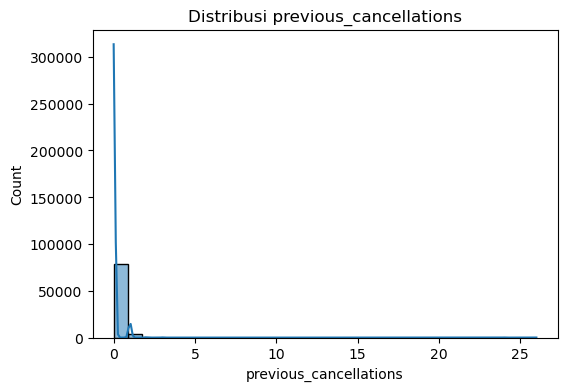

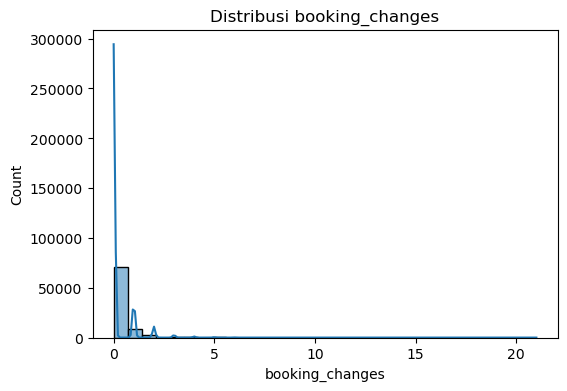

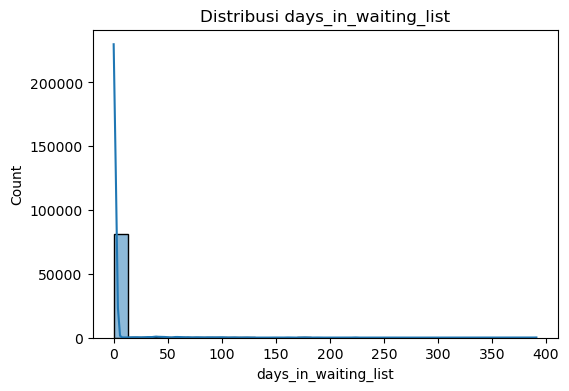

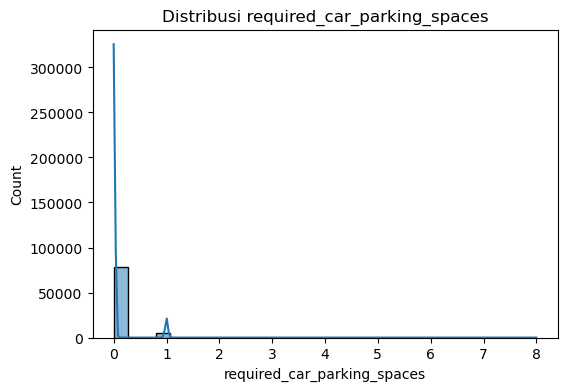

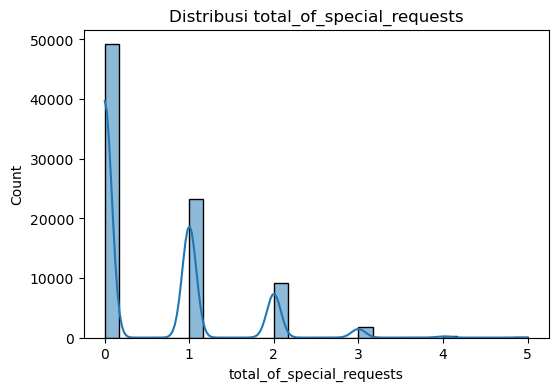

In [16]:
#Distribusi Numerik
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()


- Sebagian besar fitur numerik memiliki distribusi **right-skewed**
- Mayoritas tamu tidak memiliki histori pembatalan sebelumnya
- Perubahan pemesanan (`booking_changes`) relatif jarang
- Sebagian besar tamu tidak menggunakan waiting list
- Permintaan khusus dan kebutuhan parkir cenderung rendah


## 4.4 Univariate Analysis – Categorical Features
**Daftar Fitur Kategorikal**
- country
- market_segment
- deposit_type
- customer_type
- reserved_room_type

In [17]:
# Daftar Fitur Kategorikal
categorical_cols = [
    'country',
    'market_segment',
    'deposit_type',
    'customer_type',
    'reserved_room_type'
]


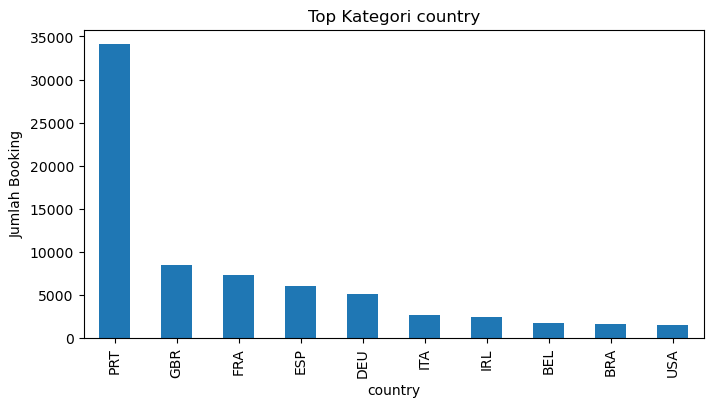

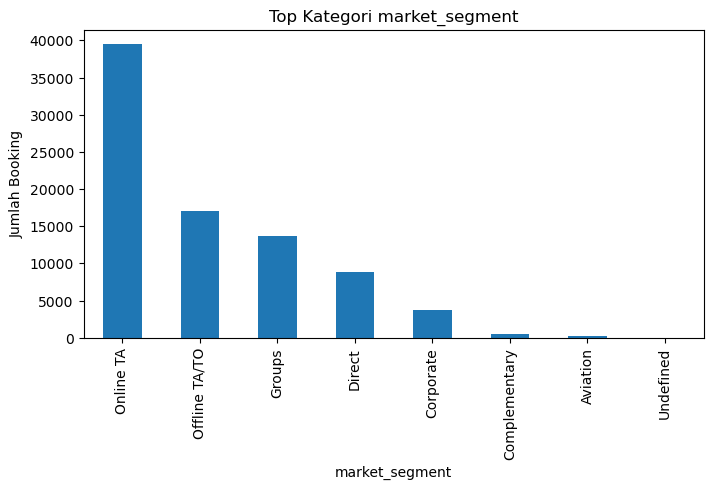

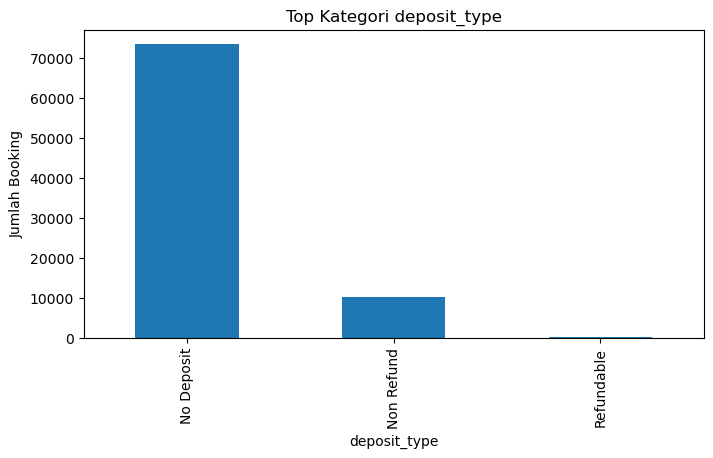

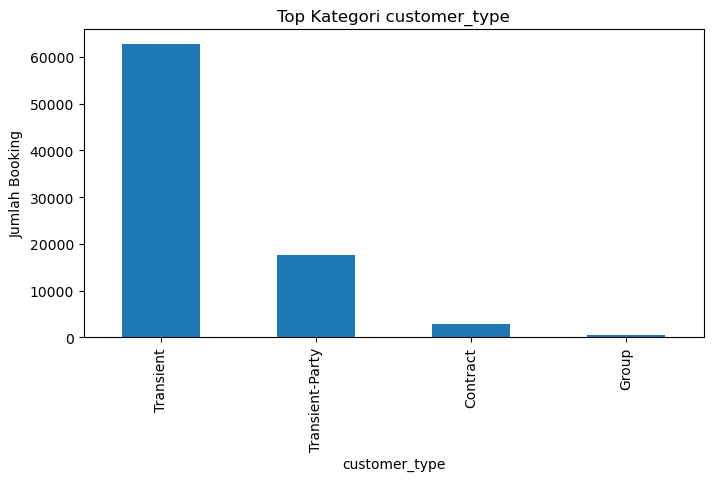

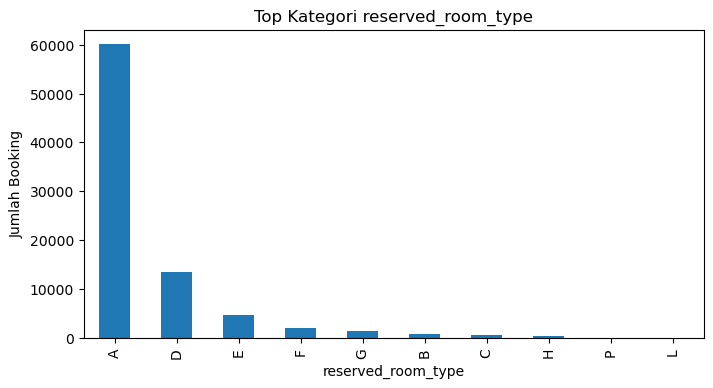

In [18]:
# Distribusi Kategori
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top Kategori {col}')
    plt.ylabel('Jumlah Booking')
    plt.show()


- Beberapa fitur memiliki **kategori dominan**, seperti:
  - Negara asal tertentu
  - Segmentasi pasar Online TA
  - Tipe deposit No Deposit
- Beberapa fitur memiliki **kardinalitas tinggi** (misalnya `country`)
- Hal ini perlu diperhatikan saat proses encoding dan feature engineering


## 4.5 Bivariate Analysis – Numerical vs Target

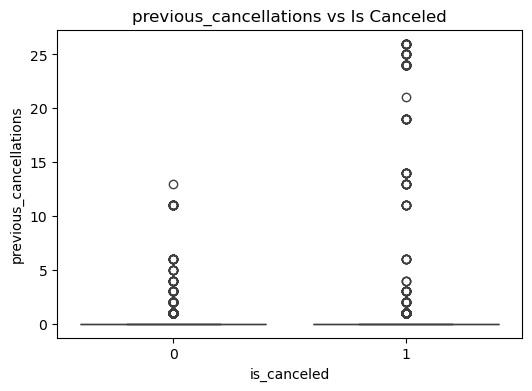

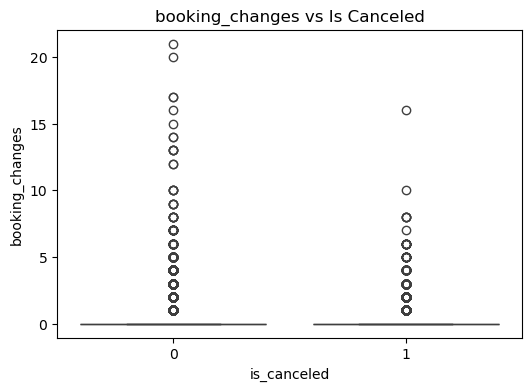

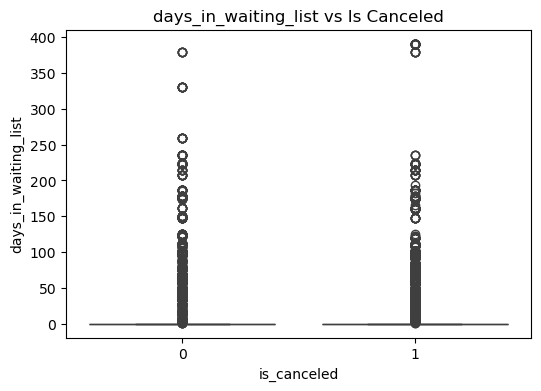

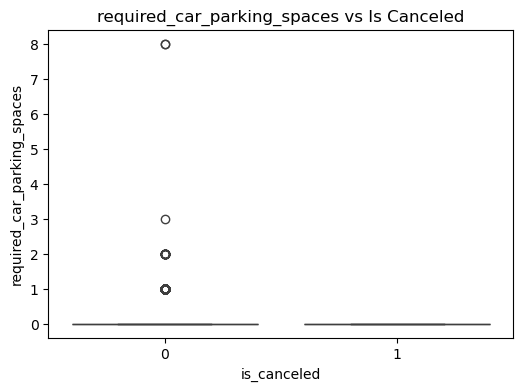

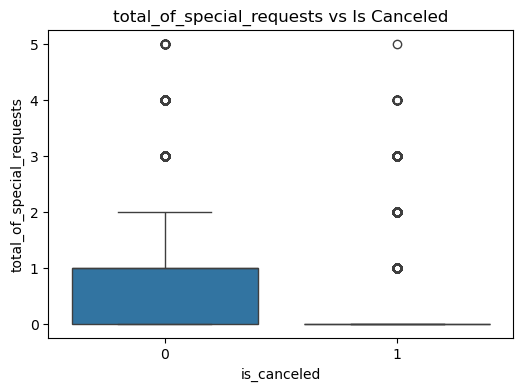

In [19]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='is_canceled', y=col, data=df)
    plt.title(f'{col} vs Is Canceled')
    plt.show()


- Booking dengan histori pembatalan sebelumnya cenderung memiliki risiko cancel lebih tinggi
- Jumlah perubahan booking yang lebih tinggi berkorelasi dengan pembatalan
- Pemesanan yang pernah masuk waiting list menunjukkan kecenderungan dibatalkan
- Tamu dengan banyak permintaan khusus cenderung lebih serius dan lebih jarang membatalkan


## 4.6 Bivariate Analysis – Categorical vs Target

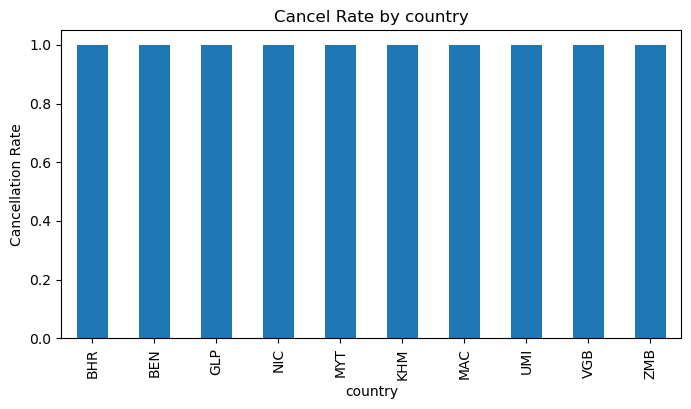

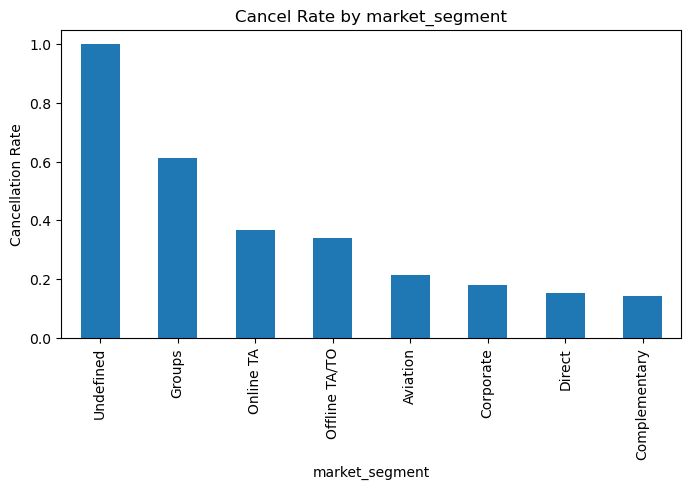

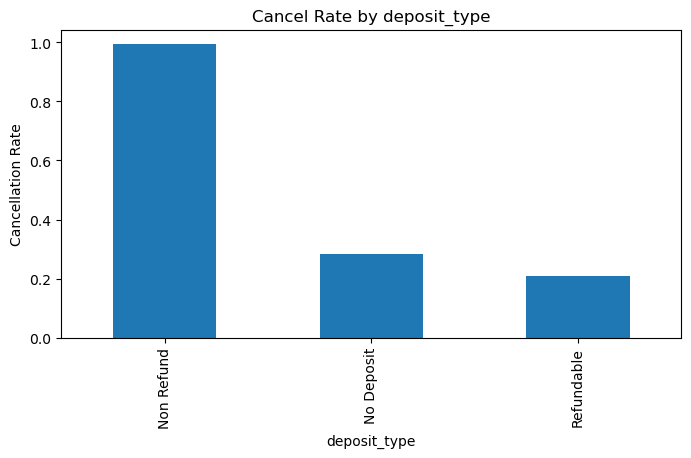

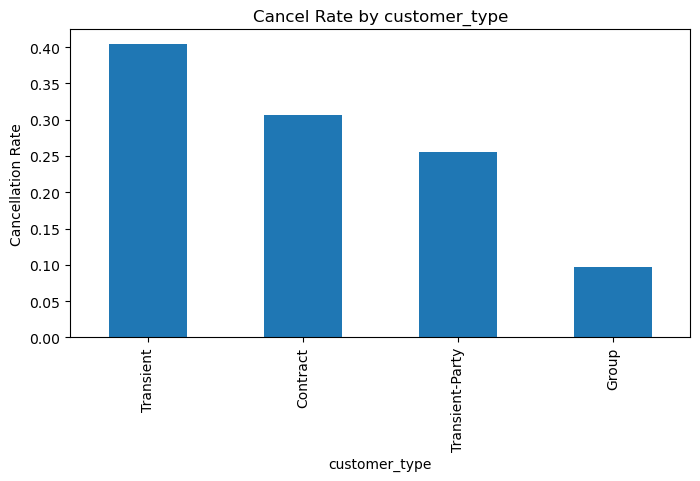

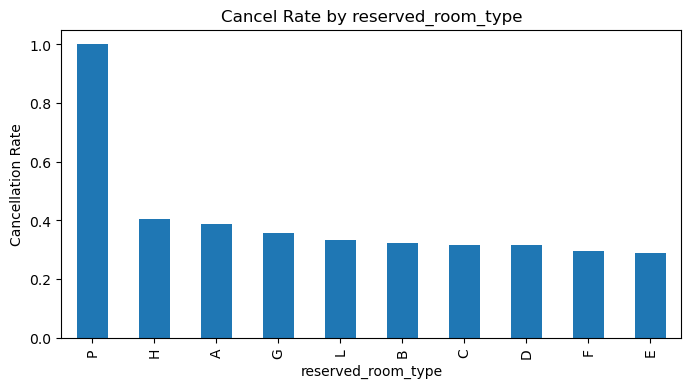

In [20]:
for col in categorical_cols:
    cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8,4))
    cancel_rate.head(10).plot(kind='bar')
    plt.title(f'Cancel Rate by {col}')
    plt.ylabel('Cancellation Rate')
    plt.show()


- Beberapa market segment memiliki tingkat pembatalan lebih tinggi dibandingkan yang lain
- Booking dengan tipe deposit tertentu menunjukkan perilaku pembatalan yang sangat berbeda
- Tipe pelanggan (customer_type) berpengaruh signifikan terhadap risiko pembatalan
- Informasi ini sangat penting untuk strategi overbooking dan revenue management


## 4.7 Correlation Analysis (Numerical Features)

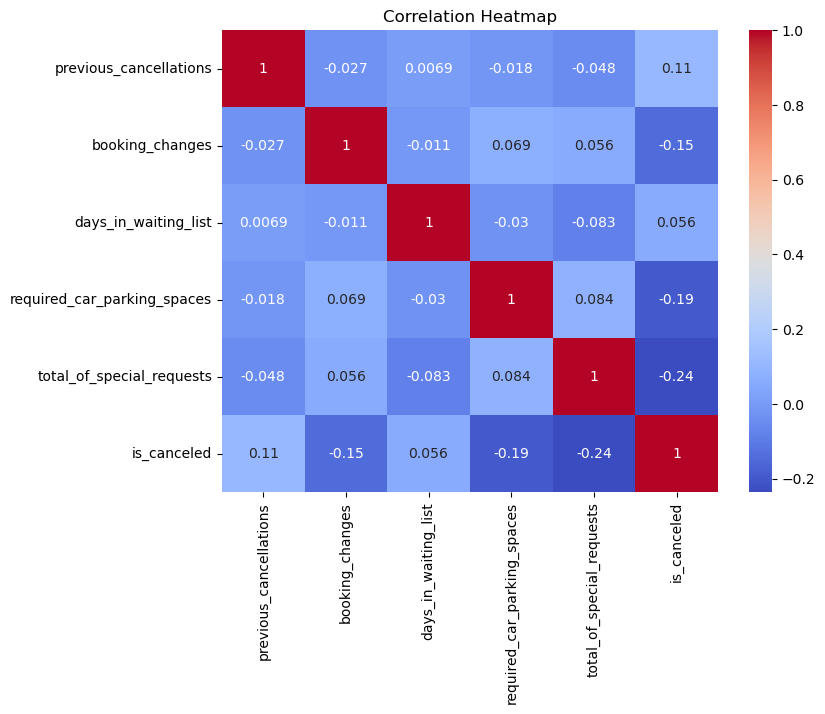

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols + ['is_canceled']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


- Korelasi antar fitur numerik relatif rendah
- Tidak terdapat multikolinearitas yang signifikan
- Beberapa fitur memiliki korelasi positif terhadap `is_canceled`, meskipun tidak kuat
- Hal ini mengindikasikan bahwa model non-linear kemungkinan akan bekerja lebih baik


## 4.8 Ringkasan Insight EDA
Berdasarkan hasil EDA, dapat disimpulkan bahwa:

- Dataset bersifat imbalanced dan mencerminkan kondisi bisnis nyata
- Faktor historis perilaku tamu sangat memengaruhi pembatalan
- Fitur kategorikal memiliki pengaruh signifikan terhadap target
- Informasi EDA mendukung penggunaan model ensemble dan teknik penanganan imbalance
- Insight ini menjadi dasar kuat untuk tahap Feature Engineering dan Modeling


# 5. Data Preparation

Tahapan **Data Preparation** merupakan proses penting dalam pipeline machine learning yang bertujuan untuk mempersiapkan data sebelum digunakan dalam proses pelatihan model. Data mentah umumnya belum siap digunakan secara langsung karena dapat mengandung nilai kosong, tipe data yang tidak sesuai, variabel kategorikal yang belum dikodekan, serta skala fitur yang berbeda.

Pada penelitian ini, tahap Data Preparation meliputi beberapa proses utama yaitu:

1. Pemeriksaan Missing Values
2. Pemeriksaan Duplikasi Data
3. Analisis Fitur
4. Pemilihan dan Penghapusan Fitur
5. Encoding Variabel Kategorikal
6. Feature Scaling
7. Pemisahan Data Latih dan Data Uji

Tujuan dari tahapan ini adalah untuk memastikan bahwa data yang digunakan dalam proses pelatihan model memiliki kualitas yang baik, konsisten, dan sesuai dengan kebutuhan algoritma machine learning.

## 5.1 Pembuatan Dataset untuk Modelling

Pada tahap ini dibuat salinan dataset yang akan digunakan khusus untuk proses pemodelan machine learning. Hal ini dilakukan agar dataset asli yang telah melalui tahap data cleaning tetap terjaga sebagai data referensi.

Pendekatan ini merupakan praktik yang umum digunakan dalam workflow data science karena memisahkan data mentah dari data yang telah melalui berbagai proses transformasi.

Dengan demikian seluruh proses feature engineering dan transformasi data dilakukan pada dataframe baru.

In [22]:
# membuat salinan dataset untuk modelling
df_model = df.copy()

df_model.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


## 5.2 Analisis Fitur

Analisis fitur dilakukan untuk memahami karakteristik setiap variabel yang terdapat pada dataset serta menentukan apakah fitur tersebut relevan untuk digunakan dalam proses pelatihan model klasifikasi pembatalan pemesanan hotel.

Dataset yang digunakan dalam penelitian ini terdiri dari dua jenis variabel utama yaitu variabel kategorikal dan variabel numerik.

#### Variabel Kategorikal

Variabel kategorikal merupakan variabel yang berisi label atau kategori tertentu yang tidak dapat langsung digunakan oleh sebagian besar algoritma machine learning.

Variabel kategorikal dalam dataset ini meliputi:

- country
- market_segment
- deposit_type
- customer_type
- reserved_room_type

Variabel-variabel ini menggambarkan karakteristik pelanggan serta tipe pemesanan yang dilakukan.

#### Variabel Numerik

Variabel numerik merupakan variabel yang memiliki nilai berupa angka dan dapat digunakan untuk melakukan perhitungan matematis.

Variabel numerik dalam dataset ini meliputi:

- previous_cancellations
- booking_changes
- days_in_waiting_list
- required_car_parking_spaces
- total_of_special_requests

Variabel numerik tersebut memberikan informasi mengenai perilaku pelanggan dalam melakukan pemesanan hotel.

#### Variabel Target

Variabel target yang digunakan dalam penelitian ini adalah:

- **is_canceled**

Variabel ini menunjukkan apakah suatu pemesanan hotel dibatalkan atau tidak.

0 = pemesanan tidak dibatalkan  
1 = pemesanan dibatalkan

## 5.3 Analisis Relevansi Fitur

Setiap fitur pada dataset dianalisis untuk menentukan apakah fitur tersebut memiliki potensi kontribusi terhadap prediksi pembatalan pemesanan.

#### **country**
Fitur ini menunjukkan negara asal pelanggan. Faktor geografis dapat mempengaruhi pola perjalanan serta kemungkinan pembatalan pemesanan. Oleh karena itu fitur ini dipertahankan.

#### **market_segment**
Fitur ini menggambarkan segmen pasar pemesanan seperti Online Travel Agent, Corporate, atau Direct Booking. Segmen pasar sering memiliki pola pembatalan yang berbeda sehingga fitur ini dipertahankan.

#### **deposit_type**
Jenis deposit yang digunakan oleh pelanggan dapat mempengaruhi komitmen pelanggan terhadap pemesanan. Pemesanan dengan deposit umumnya memiliki kemungkinan pembatalan yang lebih rendah.

#### **customer_type**
Jenis pelanggan seperti transient atau contract dapat menunjukkan pola pemesanan yang berbeda sehingga fitur ini dipertahankan.

#### **reserved_room_type**
Tipe kamar yang dipesan dapat mempengaruhi keputusan pelanggan untuk mempertahankan atau membatalkan pemesanan.

#### **previous_cancellations**
Jumlah pembatalan sebelumnya merupakan indikator kuat terhadap perilaku pembatalan di masa depan.

#### **booking_changes**
Jumlah perubahan pada pemesanan dapat menunjukkan tingkat ketidakpastian pelanggan terhadap rencana perjalanan mereka.

#### **days_in_waiting_list**
Lamanya waktu pemesanan berada dalam waiting list dapat mempengaruhi kemungkinan pembatalan.

#### **required_car_parking_spaces**
Jumlah kebutuhan parkir dapat memberikan informasi mengenai karakteristik perjalanan pelanggan.

#### **total_of_special_requests**
Jumlah permintaan khusus dapat menunjukkan tingkat komitmen pelanggan terhadap pemesanan hotel.

Berdasarkan analisis tersebut seluruh fitur dinilai memiliki potensi kontribusi terhadap model sehingga tidak dilakukan penghapusan fitur pada tahap ini.

## 5.4 Feature Engineering

Feature Engineering merupakan proses pembuatan fitur baru dari fitur yang sudah ada dengan tujuan meningkatkan kemampuan model dalam menangkap pola pada data.

Pada penelitian ini dibuat beberapa fitur tambahan berbasis variabel numerik yang dapat merepresentasikan perilaku pelanggan dalam melakukan pemesanan hotel.

Fitur yang dibuat antara lain:

1. **has_previous_cancellation**

Fitur ini menunjukkan apakah pelanggan pernah melakukan pembatalan sebelumnya.

Perhitungan:

has_previous_cancellation = 1 jika previous_cancellations > 0  
has_previous_cancellation = 0 jika previous_cancellations = 0

2. **has_special_requests**

Fitur ini menunjukkan apakah pelanggan memiliki permintaan khusus terhadap pemesanan hotel.

Perhitungan:

has_special_requests = 1 jika total_of_special_requests > 0  
has_special_requests = 0 jika total_of_special_requests = 0

3. **multiple_booking_changes**

Fitur ini menunjukkan apakah pelanggan melakukan lebih dari satu perubahan pada pemesanan.

Perhitungan:

multiple_booking_changes = 1 jika booking_changes > 1  
multiple_booking_changes = 0 jika booking_changes ≤ 1

Fitur-fitur ini dibuat untuk membantu model mengenali pola perilaku pelanggan secara lebih sederhana melalui representasi variabel biner.

In [23]:
# Feature Engineering

df_model['has_previous_cancellation'] = (df_model['previous_cancellations'] > 0).astype(int)

df_model['has_special_requests'] = (df_model['total_of_special_requests'] > 0).astype(int)

df_model['multiple_booking_changes'] = (df_model['booking_changes'] > 1).astype(int)

df_model.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled,has_previous_cancellation,has_special_requests,multiple_booking_changes
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0,0,1,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0,0,1,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1,0,1,0
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0,0,1,1


## 5.5 Pemisahan Fitur dan Target

Dalam supervised learning, dataset perlu dipisahkan menjadi dua komponen utama yaitu fitur (X) dan target (y).

Fitur merupakan variabel independen yang digunakan sebagai input untuk model machine learning, sedangkan target merupakan variabel yang ingin diprediksi oleh model.

Pada penelitian ini variabel target yang digunakan adalah **is_canceled** yang menunjukkan apakah suatu pemesanan hotel dibatalkan atau tidak.

In [24]:
# memisahkan fitur dan target

X = df_model.drop("is_canceled", axis=1)

y = df_model["is_canceled"]

print("Shape fitur:", X.shape)
print("Shape target:", y.shape)

Shape fitur: (83573, 13)
Shape target: (83573,)


## 5.6 Identifikasi Tipe Fitur
Identifikasi tipe fitur dilakukan untuk menentukan metode preprocessing yang tepat untuk setiap jenis data.

Secara umum dataset terdiri dari dua jenis fitur utama:

1. **Fitur numerik**

Fitur yang memiliki nilai berupa angka dan dapat digunakan langsung dalam perhitungan matematis.

2. **Fitur kategorikal**

Fitur yang berisi label kategori tertentu dan perlu dikonversi menjadi bentuk numerik melalui proses encoding sebelum digunakan dalam algoritma machine learning.

Proses identifikasi tipe fitur ini penting karena setiap tipe fitur akan diproses dengan metode preprocessing yang berbeda.

In [25]:
# identifikasi fitur kategorikal dan numerik

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['country', 'market_segment', 'deposit_type', 'customer_type', 'reserved_room_type']

Numerical Features:
['previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests', 'has_previous_cancellation', 'has_special_requests', 'multiple_booking_changes']


## 5.7 Encoding Variabel Kategorikal

Sebagian besar algoritma machine learning hanya dapat memproses data dalam bentuk numerik. Oleh karena itu, fitur kategorikal perlu dikonversi menjadi representasi numerik melalui proses encoding.

Pada penelitian ini digunakan metode **One Hot Encoding**.

### Cara Kerja One Hot Encoding

Metode ini bekerja dengan cara mengubah setiap kategori menjadi kolom biner baru. Setiap kategori akan direpresentasikan dengan nilai:

1 = kategori tersebut muncul  
0 = kategori tersebut tidak muncul

Contoh:

market_segment

| market_segment | Online_TA | Corporate |
|---|---|---|
| Online_TA | 1 | 0 |
| Corporate | 0 | 1 |

### Alasan Pemilihan One Hot Encoding

1. Menghindari asumsi hubungan ordinal antar kategori
2. Cocok untuk fitur yang tidak memiliki urutan alami
3. Banyak digunakan dalam model machine learning berbasis klasifikasi

In [26]:
df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded.head()

,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,is_canceled,has_previous_cancellation,has_special_requests,multiple_booking_changes,country_AGO,country_AIA,country_ALB,country_AND,country_ARE,country_ARG,country_ARM,country_ATA,country_AUS,country_AUT,country_AZE,country_BDI,country_BEL,country_BEN,country_BFA,country_BGD,country_BGR,country_BHR,country_BIH,country_BLR,country_BOL,country_BRA,country_BRB,country_BWA,country_CAF,country_CHE,country_CHL,country_CHN,country_CIV,country_CMR,country_CN,country_COL,country_COM,country_CPV,country_CRI,country_CUB,country_CYM,country_CYP,country_CZE,country_DEU,country_DMA,country_DNK,country_DOM,country_DZA,country_ECU,country_EGY,country_ESP,country_EST,country_ETH,country_FIN,country_FRA,country_FRO,country_GAB,country_GBR,country_GEO,country_GGY,country_GHA,country_GIB,country_GLP,country_GNB,country_GRC,country_GTM,country_HKG,country_HRV,country_HUN,country_IDN,country_IMN,country_IND,country_IRL,country_IRN,country_IRQ,country_ISL,country_ISR,country_ITA,country_JAM,country_JEY,country_JOR,country_JPN,country_KAZ,country_KEN,country_KHM,country_KIR,country_KNA,country_KOR,country_KWT,country_LAO,country_LBN,country_LBY,country_LCA,country_LIE,country_LKA,country_LTU,country_LUX,country_LVA,country_MAC,country_MAR,country_MDV,country_MEX,country_MKD,country_MLI,country_MLT,country_MMR,country_MNE,country_MOZ,country_MUS,country_MWI,country_MYS,country_MYT,country_NCL,country_NGA,country_NIC,country_NLD,country_NOR,country_NZL,country_OMN,country_PAK,country_PAN,country_PER,country_PHL,country_PLW,country_POL,country_PRI,country_PRT,country_PRY,country_QAT,country_ROU,country_RUS,country_RWA,country_SAU,country_SDN,country_SEN,country_SGP,country_SLE,country_SLV,country_SRB,country_SUR,country_SVK,country_SVN,country_SWE,country_SYC,country_SYR,country_TGO,country_THA,country_TJK,country_TMP,country_TUN,country_TUR,country_TWN,country_TZA,country_UGA,country_UKR,country_UMI,country_URY,country_USA,country_UZB,country_Unknown,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P
0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,0,0,0,0,2,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

## 5.8 Feature Scaling

Feature Scaling merupakan proses untuk menyesuaikan skala nilai dari setiap fitur numerik agar berada pada rentang yang sebanding. Hal ini penting karena beberapa algoritma machine learning sensitif terhadap perbedaan skala antar fitur.

Sebagai contoh, fitur dengan rentang nilai yang lebih besar dapat mendominasi proses pembelajaran model.

Pada penelitian ini digunakan metode **Standard Scaler**.

### Cara Kerja Standard Scaler

Standard Scaler melakukan transformasi data menggunakan rumus berikut:

Z = (X − μ) / σ

Dimana:

X = nilai asli  
μ = rata-rata fitur  
σ = standar deviasi fitur  

Hasil transformasi akan menghasilkan distribusi dengan:

mean = 0  
standard deviation = 1

### Alasan Pemilihan Standard Scaler

1. Banyak algoritma machine learning seperti Logistic Regression, SVM, dan KNN bekerja lebih optimal dengan data yang terstandarisasi
2. Mengurangi pengaruh perbedaan skala antar fitur
3. Membantu mempercepat konvergensi pada proses pelatihan model

In [27]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("is_canceled", axis=1)
y = df_encoded["is_canceled"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 5.9 Train-Test Split

Dataset dibagi menjadi data latih dan data uji dengan rasio 80:20.
Stratified split digunakan untuk menjaga proporsi kelas target pada kedua subset data.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Jumlah data latih:", X_train.shape)
print("Jumlah data uji:", X_test.shape)

Jumlah data latih: (66858, 191)
Jumlah data uji: (16715, 191)


## 5.10 Column Transformer
Untuk menggabungkan seluruh proses preprocessing ke dalam satu pipeline yang konsisten dan bebas data leakage,
digunakan ColumnTransformer yang memproses fitur numerik dan kategorikal secara terpisah.


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as skPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', skPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features)
    ],
    remainder='passthrough'
)

## 5.11 Ringkasan Tahap Data Preparation

### Ringkasan Tahap Data Preparation

Pada tahap Data Preparation telah dilakukan beberapa proses penting untuk mempersiapkan dataset sebelum digunakan dalam proses pelatihan model machine learning.

Tahapan tersebut meliputi:

1. Pembuatan dataset modelling
2. Pemisahan fitur dan target
3. Identifikasi tipe fitur
4. Analisis fitur
5. Feature engineering
6. Train-test split
7. Transformasi fitur menggunakan ColumnTransformer

Hasil dari tahap ini adalah dataset yang telah melalui proses transformasi sehingga siap digunakan pada tahap pemodelan machine learning.


# 6. Modelling

Pada tahap ini, kita akan membangun model prediktif untuk mengklasifikasikan apakah sebuah pemesanan akan dibatalkan (`is_canceled = 1`) atau tidak. 

Model yang dibangun bertujuan untuk mengklasifikasikan apakah suatu pemesanan hotel akan dibatalkan atau tidak berdasarkan fitur-fitur yang tersedia pada dataset.

Tahap ini meliputi beberapa proses utama yaitu:

1. Pemilihan algoritma klasifikasi
2. Pelatihan model baseline
3. Evaluasi model menggunakan cross-validation
4. Analisis overfitting
5. Hyperparameter tuning
6. Pemilihan model final

### **Konsistensi Metrik Evaluasi**
Sesuai dengan tujuan bisnis untuk meminimalkan kehilangan pendapatan akibat kamar kosong (*False Negative*), metrik utama yang digunakan secara konsisten dari tahap *benchmarking* hingga *hyperparameter tuning* adalah **Recall**.

* **Recall (Sensitivitas):** Sejauh mana model mampu menangkap semua tamu yang sebenarnya membatalkan pesanan.
* **Stabilitas:** Diukur melalui nilai Standar Deviasi (Std) dari hasil Cross-Validation.
* **Overfitting Check:** Membandingkan performa model pada data latih (*training score*) dan data validasi (*test score*).

## 6.2 Pemilihan Metrik Evaluasi

Metrik utama yang digunakan dalam penelitian ini adalah **Recall**.

Recall dihitung dengan rumus:

Recall = TP / (TP + FN)

Dimana:

TP = True Positive  
FN = False Negative  

Recall mengukur kemampuan model dalam mendeteksi seluruh kasus positif yang sebenarnya.

Dalam konteks prediksi pembatalan hotel:

- Kelas positif = reservasi yang dibatalkan
- False Negative berarti model gagal mendeteksi reservasi yang akan dibatalkan

Kesalahan ini sangat merugikan bagi pihak hotel karena kamar yang dibatalkan tidak dapat segera dijual kembali.

Oleh karena itu, **Recall dipilih sebagai metrik utama** agar model mampu menangkap sebanyak mungkin potensi pembatalan reservasi.

Seluruh proses evaluasi dan hyperparameter tuning pada penelitian ini menggunakan **Recall sebagai metrik evaluasi** agar konsisten dengan tujuan proyek.

## 6.1 Tujuan Modelling

Tujuan dari tahap modelling adalah membangun model machine learning yang mampu memprediksi kemungkinan pembatalan pemesanan hotel berdasarkan karakteristik reservasi yang tersedia pada dataset.

Model yang dibangun diharapkan mampu:

- Mengidentifikasi reservasi yang berpotensi dibatalkan
- Membantu pihak hotel dalam melakukan manajemen ketersediaan kamar
- Mengurangi kerugian akibat pembatalan reservasi yang tidak terprediksi

Untuk mencapai tujuan tersebut, beberapa algoritma machine learning akan dibandingkan performanya untuk menentukan model terbaik.

## 6.3 Model Kandidat

Beberapa algoritma machine learning digunakan untuk membandingkan performa model, yaitu:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM

Alasan pemilihan model tersebut adalah:

- Logistic Regression digunakan sebagai baseline model karena sederhana dan mudah diinterpretasikan.
- Decision Tree mampu menangkap hubungan non-linear antar fitur.
- Random Forest merupakan metode ensemble yang meningkatkan stabilitas Decision Tree.
- XGBoost dan LightGBM merupakan algoritma gradient boosting yang dikenal memiliki performa tinggi pada dataset tabular.

Dengan membandingkan beberapa algoritma, diharapkan dapat diperoleh model dengan performa terbaik untuk memprediksi pembatalan reservasi hotel.

In [30]:
# Import library modelling

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import lightgbm as lgb

In [31]:
# Definisi model kandidat

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": lgb.LGBMClassifier(
        random_state=42
    )
}

## 6.4 Pembangunan Pipeline Modelling

Untuk memastikan proses preprocessing dilakukan secara konsisten dan menghindari data leakage, seluruh proses modelling dimasukkan ke dalam pipeline.

Pipeline terdiri dari beberapa tahapan:

1. Preprocessing fitur menggunakan `ColumnTransformer`
2. Penanganan ketidakseimbangan kelas menggunakan `RandomOverSampler`
3. Training model machine learning

Pendekatan pipeline memastikan bahwa setiap tahap preprocessing dipelajari hanya dari data training pada setiap fold cross-validation.

In [32]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipelines = {}

for name, model in models.items():

    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('oversampling', ros),
        ('model', model)
    ])

    pipelines[name] = pipeline

## 6.5 Evaluasi Model Menggunakan Cross Validation

Evaluasi awal dilakukan menggunakan **K-Fold Cross Validation dengan 5 fold**.

Cross-validation digunakan untuk:

- Mengurangi bias dari pembagian data
- Mengukur kemampuan generalisasi model
- Menghasilkan evaluasi yang lebih stabil

Selain menghitung rata-rata nilai Recall, juga dihitung **standar deviasi (std)** dari hasil cross-validation untuk mengukur kestabilan performa model.

In [34]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean Recall": scores.mean(),
        "Std Recall": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

cv_results

,Model,Mean Recall,Std Recall
0,Logistic Regression,0.766388,0.010862
1,Decision Tree,0.797295,0.007531
2,Random Forest,0.680975,0.023629
3,XGBoost,0.791487,0.008973
4,LightGBM,0.790188,0.008953


## 6.6 Analisis Kestabilan Model

Nilai standar deviasi dari cross-validation digunakan untuk menganalisis kestabilan model.

Interpretasi:

- **Standar deviasi kecil** menunjukkan model memiliki performa yang stabil pada berbagai subset data.
- **Standar deviasi besar** menunjukkan performa model tidak stabil.

Model yang baik diharapkan memiliki:

- Mean Recall tinggi
- Standar deviasi kecil

## 6.7 Identifikasi Overfitting

Overfitting terjadi ketika model memiliki performa yang sangat baik pada data training tetapi buruk pada data validasi.

Untuk mendeteksi overfitting dilakukan perbandingan antara:

- Training Recall
- Validation Recall

Jika nilai Training Recall jauh lebih tinggi dibandingkan Validation Recall, maka model kemungkinan mengalami overfitting.

In [35]:
from sklearn.model_selection import cross_validate
overfit_results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="recall",
        return_train_score=True,
        n_jobs=-1
    )

    overfit_results.append({
        "Model": name,
        "Train Recall Mean": scores["train_score"].mean(),
        "Validation Recall Mean": scores["test_score"].mean(),
        "Validation Std": scores["test_score"].std()
    })

pd.DataFrame(overfit_results)

,Model,Train Recall Mean,Validation Recall Mean,Validation Std
0,Logistic Regression,0.768002,0.766388,0.010862
1,Decision Tree,0.829675,0.797295,0.007531
2,Random Forest,0.679972,0.680975,0.023629
3,XGBoost,0.799488,0.791487,0.008973
4,LightGBM,0.796747,0.790188,0.008953


# 7. Hyperparameter Tuning

Setelah evaluasi baseline model dilakukan, tahap selanjutnya adalah melakukan hyperparameter tuning untuk meningkatkan performa model.

Metode yang digunakan adalah **RandomizedSearchCV** karena lebih efisien dibandingkan GridSearchCV ketika jumlah kombinasi parameter cukup besar.

Proses tuning tetap menggunakan **Recall sebagai metrik evaluasi** agar konsisten dengan tujuan penelitian.

In [36]:
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# ========================
# PARAMETER SPACE
# ========================
rf_param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

# ========================
# PIPELINE
# ========================
rf_pipeline = pipelines["Random Forest"]

# ========================
# RANDOM SEARCH
# ========================
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# ========================
# FIT
# ========================
rf_random_search.fit(X_train, y_train)

# ========================
# BEST MODEL
# ========================
best_model = rf_random_search.best_estimator_

print("Best Recall (CV):", rf_random_search.best_score_)
print("Best Parameters:", rf_random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Recall (CV): 0.8003409716008199
Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [37]:
results_df = pd.DataFrame(rf_random_search.cv_results_)

results_df = results_df.sort_values(by="mean_test_score", ascending=False)

results_df[[
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].head()

,mean_test_score,std_test_score,mean_train_score
10,0.800341,0.008098,0.832416
15,0.799650,0.008420,0.835107
2,0.798960,0.008368,0.831421
17,0.798635,0.008340,0.827096
18,0.783486,0.008543,0.795579


## 7.1 Hyperparameter Terbaik

Berdasarkan proses RandomizedSearchCV, diperoleh kombinasi hyperparameter terbaik yang menghasilkan nilai Recall tertinggi.

Parameter ini akan digunakan sebagai model final dalam tahap evaluasi selanjutnya. Evaluasi Model Final

Model terbaik yang diperoleh dari proses hyperparameter tuning kemudian dievaluasi menggunakan data testing yang tidak digunakan selama proses training.

Evaluasi dilakukan menggunakan classification report untuk melihat performa model secara menyeluruh.

In [38]:
best_params = rf_random_search.best_params_
best_recall = rf_random_search.best_score_

print("Best Recall:", best_recall)
print("Best Parameters:", best_params)

Best Recall: 0.8003409716008199
Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [39]:
pd.DataFrame({
    "Best Recall": [best_recall],
    "Best Parameters": [best_params]
})

,Best Recall,Best Parameters
0,0.800341,"{'model__n_estimators': 300, 'model__min_sampl..."


## 7.2 Evaluasi Model: Default vs Tuned

Pada tahap ini dilakukan perbandingan antara model Random Forest sebelum dan sesudah hyperparameter tuning.

Tujuannya adalah untuk mengevaluasi apakah tuning memberikan peningkatan performa, khususnya pada metrik Recall.

Selain itu, juga dianalisis kestabilan model menggunakan standar deviasi dari cross-validation.

In [40]:
from sklearn.model_selection import cross_val_score

# ========================
# DEFAULT MODEL
# ========================
rf_default = pipelines["Random Forest"]

rf_default_scores = cross_val_score(
    rf_default,
    X_train,
    y_train,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

# ========================
# TUNED MODEL
# ========================
rf_tuned = best_model

rf_tuned_scores = cross_val_score(
    rf_tuned,
    X_train,
    y_train,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

# ========================
# COMPARISON
# ========================
comparison_df = pd.DataFrame({
    "Model": ["Random Forest (Default)", "Random Forest (Tuned)"],
    "Mean Recall": [rf_default_scores.mean(), rf_tuned_scores.mean()],
    "Std Recall": [rf_default_scores.std(), rf_tuned_scores.std()]
})

comparison_df

,Model,Mean Recall,Std Recall
0,Random Forest (Default),0.680975,0.023629
1,Random Forest (Tuned),0.800341,0.008098


In [41]:
print("Default Model Recall Mean:", rf_default_scores.mean())
print("Default Model Recall Std:", rf_default_scores.std())

print("\nTuned Model Recall Mean:", rf_tuned_scores.mean())
print("Tuned Model Recall Std:", rf_tuned_scores.std())

Default Model Recall Mean: 0.6809746935140017
Default Model Recall Std: 0.023628716868926206

Tuned Model Recall Mean: 0.8003409716008199
Tuned Model Recall Std: 0.008097877127339653


Hasil evaluasi menunjukkan bahwa model Random Forest setelah dilakukan hyperparameter tuning mengalami peningkatan nilai Recall dibandingkan model default.

Selain itu, nilai standar deviasi yang relatif kecil menunjukkan bahwa model memiliki performa yang stabil pada berbagai subset data.

Dengan demikian, model hasil tuning dipilih sebagai model final karena mampu memberikan keseimbangan antara performa dan stabilitas.

# Model Evaluation

Model Random Forest dipilih sebagai model terbaik karena memiliki performa Recall tertinggi dibandingkan model lainnya dalam mendeteksi pembatalan pemesanan.

## Model Performance

Berdasarkan hasil evaluasi, model Random Forest menghasilkan:

- **Recall: 80%**

## Interpretasi

Nilai Recall sebesar **80%** menunjukkan bahwa model mampu mendeteksi sekitar **80% dari seluruh kasus pembatalan yang sebenarnya terjadi**.

Dalam konteks bisnis hotel:
- False Negative (tidak terdeteksi cancel) → berisiko kamar kosong dan kehilangan revenue
- False Positive → hanya berdampak pada strategi mitigasi (lebih aman)

Oleh karena itu, model ini dirancang untuk **memaksimalkan deteksi pembatalan**, meskipun harus mengorbankan sebagian precision.

## Kesimpulan

Model Random Forest dinilai paling optimal karena mampu memberikan keseimbangan antara performa dan kebutuhan bisnis, dengan fokus utama pada kemampuan mendeteksi potensi pembatalan secara maksimal.

# 8. Mekanisme Kerja Model Final

Model terbaik yang diperoleh dalam penelitian ini adalah **Random Forest Classifier**.

Random Forest merupakan algoritma ensemble yang bekerja dengan membangun banyak Decision Tree dan menggabungkan prediksi dari seluruh pohon tersebut.

Proses kerja Random Forest adalah sebagai berikut:

1. Dataset training diambil secara acak menggunakan teknik bootstrap sampling untuk membentuk beberapa subset data.
2. Pada setiap subset data dibangun sebuah Decision Tree.
3. Saat membangun setiap node, hanya sebagian fitur yang dipilih secara acak untuk menentukan split terbaik.
4. Setiap Decision Tree menghasilkan prediksi independen.
5. Prediksi akhir ditentukan melalui mekanisme **majority voting** dari seluruh pohon.

Keunggulan Random Forest antara lain:

- Mengurangi risiko overfitting dibandingkan Decision Tree tunggal
- Mampu menangkap hubungan non-linear antar fitur
- Memiliki performa yang stabil pada dataset tabular

Dalam konteks prediksi pembatalan reservasi hotel, Random Forest mampu mempelajari pola kompleks antara fitur seperti lead time, jenis pelanggan, jumlah tamu, dan permintaan khusus pelanggan terhadap kemungkinan pembatalan reservasi.

## 8.1 Perbandingan Performa Model

Perbandingan performa model dilakukan menggunakan metrik **Recall** dari hasil cross-validation.

Selain nilai rata-rata Recall, juga ditampilkan standar deviasi (std) untuk melihat kestabilan model.

Model dengan Recall tinggi dan standar deviasi rendah dianggap lebih baik.

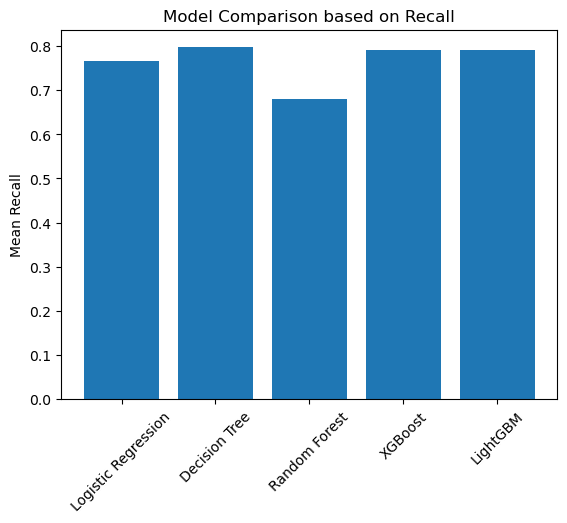

In [42]:
import matplotlib.pyplot as plt

# Misalnya sudah punya dataframe cv_results
# cv_results = pd.DataFrame({
#     "Model": [...],
#     "Mean Recall": [...],
#     "Std Recall": [...]
# })

plt.figure()
plt.bar(cv_results["Model"], cv_results["Mean Recall"])
plt.xticks(rotation=45)
plt.ylabel("Mean Recall")
plt.title("Model Comparison based on Recall")
plt.show()

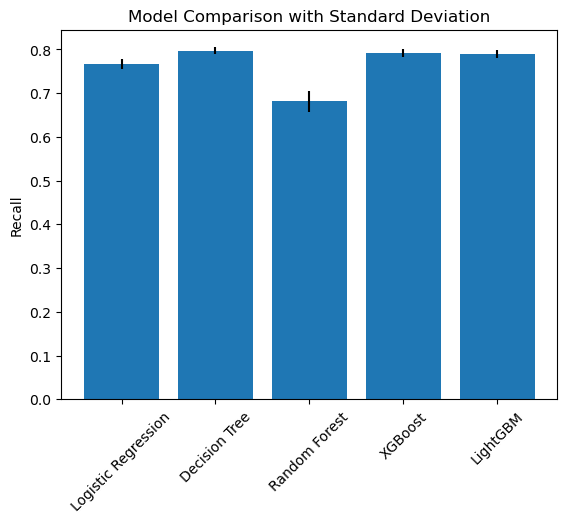

In [43]:
plt.figure()
plt.bar(
    cv_results["Model"],
    cv_results["Mean Recall"],
    yerr=cv_results["Std Recall"]
)
plt.xticks(rotation=45)
plt.ylabel("Recall")
plt.title("Model Comparison with Standard Deviation")
plt.show()

Berdasarkan hasil perbandingan performa model menggunakan metrik Recall, terlihat bahwa model Random Forest memiliki nilai Recall tertinggi dibandingkan model lainnya.

Hal ini menunjukkan bahwa Random Forest lebih mampu dalam mendeteksi kasus pembatalan pemesanan dibandingkan model lain.

Selain itu, nilai standar deviasi yang relatif kecil menunjukkan bahwa performa model cukup stabil pada berbagai subset data.

Model seperti Logistic Regression memiliki performa yang lebih rendah, sementara model boosting seperti XGBoost dan LightGBM menunjukkan performa yang cukup baik namun masih berada di bawah Random Forest.

Dengan demikian, Random Forest dipilih sebagai kandidat model terbaik untuk tahap selanjutnya.

# 9. Confusion Matrix (Model Final)

Confusion Matrix digunakan untuk mengevaluasi performa model klasifikasi dengan melihat jumlah prediksi yang benar dan salah.

Fokus utama pada proyek ini adalah **Recall**, yaitu kemampuan model dalam mendeteksi kasus pembatalan (cancellation).

Interpretasi:
- True Positive (TP): Prediksi cancel dan benar cancel
- False Negative (FN): Prediksi tidak cancel tapi sebenarnya cancel (ini paling penting untuk diminimalkan)
- False Positive (FP): Prediksi cancel tapi sebenarnya tidak
- True Negative (TN): Prediksi tidak cancel dan benar tidak cancel

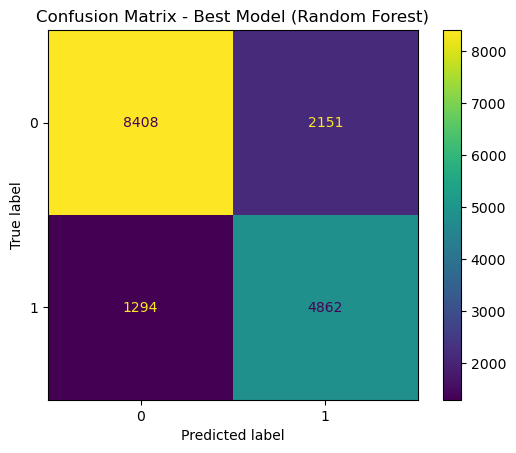

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediksi dari model terbaik
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Best Model (Random Forest)")
plt.show()

Model Random Forest menunjukkan performa yang cukup baik dengan nilai Recall sebesar 79%, yang berarti sebagian besar kasus pembatalan berhasil dideteksi.

Meskipun demikian, masih terdapat 1294 kasus False Negative yang menjadi perhatian utama karena berpotensi menyebabkan kerugian bisnis akibat pembatalan yang tidak terantisipasi.

Di sisi lain, jumlah False Positive sebesar 2151 masih dapat ditoleransi karena dampaknya relatif lebih kecil dibandingkan False Negative.

Secara keseluruhan, model sudah cukup optimal dan seimbang dalam mendeteksi kedua kelas, serta layak digunakan untuk mendukung pengambilan keputusan operasional.

## 10 Feature Importance

Feature Importance digunakan untuk mengetahui fitur mana yang paling berpengaruh dalam prediksi pembatalan pemesanan. Pada model Random Forest, feature importance dihitung berdasarkan seberapa besar kontribusi fitur dalam mengurangi impurity (Gini).

Fitur dengan nilai importance lebih tinggi memiliki pengaruh lebih besar terhadap keputusan model.

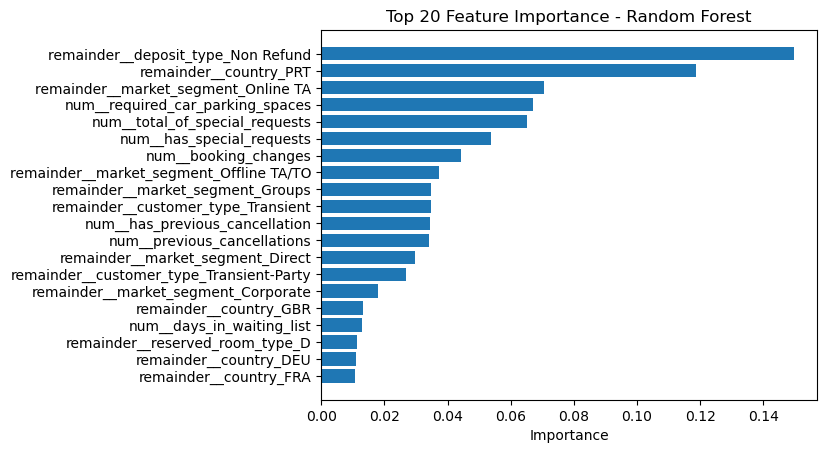

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ambil model dari pipeline
model = best_model.named_steps['model']

# Ambil nama fitur setelah preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Ambil importance
importances = model.feature_importances_

# Buat dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(20)

# Plot
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

Hasil feature importance menunjukkan bahwa faktor utama yang mempengaruhi pembatalan pemesanan adalah jenis deposit, asal negara pelanggan, serta channel pemesanan.

Fitur seperti deposit_type_Non Refund dan market_segment_Online TA memiliki kontribusi terbesar, yang menunjukkan bahwa kebijakan pembayaran dan sumber pemesanan sangat mempengaruhi keputusan pelanggan untuk membatalkan reservasi.

Selain itu, fitur perilaku seperti jumlah pembatalan sebelumnya dan perubahan booking juga menjadi indikator penting dalam memprediksi pembatalan.

Temuan ini memberikan insight bahwa strategi mitigasi pembatalan harus difokuskan pada segmentasi pelanggan berdasarkan perilaku dan channel pemesanan, bukan hanya berdasarkan karakteristik demografis.

Model tidak hanya berfungsi sebagai alat prediksi, tetapi juga sebagai alat analisis perilaku pelanggan.

Dengan memahami faktor-faktor utama yang mempengaruhi pembatalan, pihak hotel dapat mengembangkan strategi proaktif seperti:
- Penyesuaian kebijakan deposit
- Segmentasi pelanggan berbasis risiko
- Optimasi channel distribusi

Hal ini berpotensi meningkatkan revenue dan mengurangi kerugian akibat pembatalan.

## 10.1 SHAP (Shapley Additive Explanations)

Untuk meningkatkan interpretabilitas model, digunakan metode SHAP (SHapley Additive exPlanations). 

SHAP memungkinkan kita untuk memahami bagaimana setiap fitur berkontribusi terhadap prediksi model, baik secara global maupun pada level individu.

Dengan menggunakan SHAP, kita dapat:
- Mengetahui fitur mana yang paling berpengaruh
- Memahami arah pengaruh (positif / negatif)
- Menginterpretasikan keputusan model secara lebih transparan

In [46]:
# ambil preprocessor
preprocessor = best_model.named_steps['preprocessor']

# ambil model
model = best_model.named_steps['model']

In [47]:
import numpy as np

X_test_transformed = preprocessor.transform(X_test)

# cek apakah sparse atau tidak
if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

In [48]:
import shap

# sampling
X_sample = X_test_transformed[:200]

# explainer (fix error)
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="interventional"
)

# shap values
shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

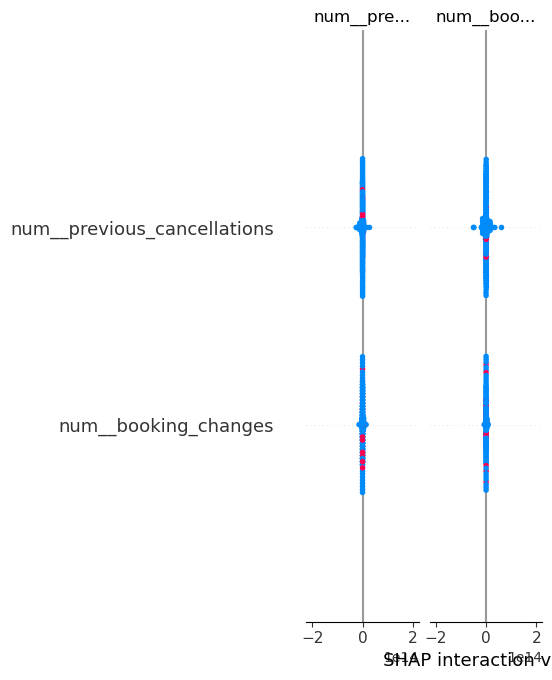

In [49]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

## 10.2 Interpretasi SHAP (SHapley Additive exPlanations)

### 1. Tujuan Analisis SHAP

Analisis SHAP (SHapley Additive exPlanations) digunakan untuk meningkatkan interpretabilitas model dengan menjelaskan bagaimana setiap fitur berkontribusi terhadap prediksi yang dihasilkan. Visualisasi SHAP memungkinkan analisis baik secara global (keseluruhan data) maupun lokal (per individu).

Pada visualisasi ini, dilakukan analisis terhadap dua fitur numerik, yaitu:

* `num__previous_cancellations`
* `num__booking_changes`

---

### 2. Interpretasi Warna pada SHAP

Dalam visualisasi SHAP, warna memiliki arti sebagai berikut:

* Warna **merah** menunjukkan nilai fitur yang tinggi
* Warna **biru** menunjukkan nilai fitur yang rendah

Interpretasi pada fitur:

* `previous_cancellations`:

  * Merah → pelanggan memiliki riwayat pembatalan tinggi
  * Biru → pelanggan jarang atau tidak pernah melakukan pembatalan
* `booking_changes`:

  * Merah → banyak perubahan dalam pemesanan
  * Biru → pemesanan stabil tanpa banyak perubahan

---

### 3. Interpretasi Nilai SHAP (Sumbu X)

Nilai SHAP menggambarkan kontribusi suatu fitur terhadap prediksi:

* Nilai SHAP positif → meningkatkan kemungkinan pembatalan
* Nilai SHAP negatif → menurunkan kemungkinan pembatalan
* Nilai mendekati nol → kontribusi kecil atau tidak signifikan

---

### 4. Analisis Distribusi Nilai SHAP

Berdasarkan visualisasi, sebagian besar titik terkonsentrasi di sekitar nilai nol, dengan rentang yang relatif sempit. Hal ini menunjukkan bahwa kedua fitur tidak memberikan kontribusi besar terhadap prediksi model.

Selain itu, tidak terdapat pola distribusi yang jelas antara warna merah dan biru terhadap arah nilai SHAP. Warna tersebar secara acak baik di sisi positif maupun negatif, yang mengindikasikan bahwa nilai tinggi atau rendah dari fitur tidak secara konsisten mempengaruhi hasil prediksi.

---

### 5. Analisis Interaksi Antar Fitur

Visualisasi ini juga menunjukkan bahwa tidak terdapat interaksi yang kuat antara fitur `previous_cancellations` dan `booking_changes`. Hal ini ditandai dengan:

* Tidak adanya pola penyebaran yang luas
* Tidak terbentuknya pola diagonal atau cluster tertentu

Dengan demikian, dapat disimpulkan bahwa kombinasi kedua fitur ini tidak memberikan efek tambahan yang signifikan terhadap prediksi model.

---

### 6. Interpretasi per Fitur

#### a. Previous Cancellations

Secara teoritis, pelanggan dengan riwayat pembatalan yang tinggi cenderung memiliki kemungkinan lebih besar untuk melakukan pembatalan kembali. Namun, hasil SHAP menunjukkan bahwa:

* Kontribusi fitur ini relatif kecil
* Tidak terdapat hubungan yang konsisten antara nilai fitur dan arah prediksi

Hal ini menunjukkan bahwa model tidak menjadikan fitur ini sebagai faktor dominan.

---

#### b. Booking Changes

Perubahan dalam pemesanan sering diasosiasikan dengan ketidakpastian pelanggan. Namun, hasil analisis menunjukkan bahwa:

* Kontribusi fitur ini juga kecil
* Tidak terdapat pola yang jelas dalam mempengaruhi prediksi

Dengan demikian, fitur ini bukan merupakan indikator utama pembatalan dalam model.

---

### 7. Insight Model

Berdasarkan hasil analisis SHAP, dapat disimpulkan bahwa:

* Model tidak bergantung secara signifikan pada kedua fitur ini
* Prediksi model lebih dipengaruhi oleh kombinasi fitur lain
* Terdapat kemungkinan bahwa informasi dari kedua fitur sudah terwakili oleh fitur lain dalam dataset

---

### 8. Insight Bisnis

Hasil analisis menunjukkan bahwa meskipun riwayat pembatalan dan perubahan pemesanan secara intuitif dianggap penting, keduanya tidak menjadi faktor utama dalam menentukan pembatalan.

Hal ini mengindikasikan bahwa keputusan pembatalan lebih dipengaruhi oleh faktor lain seperti:

* Kebijakan deposit
* Channel pemesanan
* Karakteristik pelanggan

Dengan demikian, strategi bisnis sebaiknya tidak hanya berfokus pada riwayat pelanggan, tetapi juga mempertimbangkan faktor lain yang lebih dominan dalam mempengaruhi perilaku pembatalan.

---

### 9. Kesimpulan analisis SHAP

Secara keseluruhan, analisis SHAP menunjukkan bahwa fitur `previous_cancellations` dan `booking_changes` tidak memiliki pengaruh signifikan terhadap prediksi pembatalan.

Tidak ditemukan pola hubungan yang kuat antara nilai fitur dengan arah prediksi, serta tidak terdapat interaksi yang berarti antara kedua fitur tersebut. Hal ini menunjukkan bahwa model lebih mengandalkan fitur lain yang lebih informatif dalam menentukan kemungkinan pembatalan.


# 11. Business Insight & Interpretation

Berdasarkan hasil pemodelan machine learning, ditemukan bahwa prediksi pembatalan pemesanan hotel dipengaruhi oleh kombinasi beberapa fitur utama, terutama yang berkaitan dengan kebijakan pembayaran, karakteristik pelanggan, serta pola perilaku pemesanan.

Model menunjukkan bahwa fitur seperti kebijakan deposit, channel pemesanan (market segment), serta karakteristik reservasi memiliki kontribusi yang lebih dominan dibandingkan fitur perilaku historis seperti jumlah pembatalan sebelumnya atau perubahan pemesanan. Hal ini diperkuat oleh analisis SHAP yang menunjukkan bahwa tidak semua fitur memiliki pengaruh signifikan terhadap prediksi.

Fokus penggunaan metrik Recall dalam evaluasi model juga memberikan implikasi penting, yaitu model dirancang untuk memaksimalkan kemampuan dalam mendeteksi potensi pembatalan (true positive), meskipun berpotensi meningkatkan false positive. Dalam konteks bisnis, pendekatan ini lebih menguntungkan karena memungkinkan pihak hotel untuk mengantisipasi pembatalan lebih awal.

Secara keseluruhan, hasil proyek ini menunjukkan bahwa pembatalan tidak terjadi secara acak, melainkan dapat diprediksi berdasarkan pola tertentu yang dapat dimanfaatkan untuk pengambilan keputusan yang lebih strategis.

---

## 11.1 Business Impact Analysis

## Simulasi Dampak Bisnis

Misalkan:
- Total booking: 100,000
- Tingkat pembatalan: 30%
- Model Recall: 79%

Maka:
- Total cancel aktual: 30,000
- Cancel yang berhasil dideteksi: 23,700

Jika hotel mampu mengintervensi booking berisiko tinggi (misalnya melalui deposit atau reminder), maka sebagian besar pembatalan dapat dicegah.

## Estimasi Dampak
- Jika 20% dari booking berisiko dapat diselamatkan:
  → 4,740 booking terselamatkan
- Jika rata-rata revenue per booking = $100:
  → Potensi revenue terselamatkan = **$474,000**

Model ini memberikan potensi peningkatan revenue yang signifikan serta membantu hotel dalam pengambilan keputusan berbasis data.

# 12. Conclusion

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan, dapat disimpulkan bahwa:

1. Model machine learning yang dibangun mampu memprediksi pembatalan pemesanan dengan cukup baik, terutama dalam mengidentifikasi potensi pembatalan melalui optimasi metrik Recall.

2. Tidak semua fitur memiliki pengaruh signifikan terhadap prediksi, dimana beberapa fitur seperti previous cancellations dan booking changes terbukti memiliki kontribusi yang relatif kecil.

3. Fitur yang berkaitan dengan kebijakan hotel (seperti deposit) dan karakteristik pemesanan memiliki pengaruh yang lebih besar dalam menentukan kemungkinan pembatalan.

4. Model menunjukkan bahwa pembatalan dapat diprediksi secara sistematis, sehingga memberikan peluang bagi hotel untuk melakukan tindakan preventif.

---

# 13. Recommendation

Berdasarkan hasil analisis dan model prediksi yang telah dibangun, berikut rekomendasi yang lebih actionable untuk pihak hotel:

---

## 1. Optimalisasi Kebijakan Deposit Berbasis Risiko

Hotel disarankan menerapkan kebijakan deposit secara selektif berdasarkan hasil prediksi model.

**Action:**
- Booking dengan probabilitas cancel > 70% → wajib deposit / prepayment
- Booking dengan probabilitas 40–70% → deposit parsial
- Booking < 40% → tanpa deposit

**Expected Outcome:**
Mengurangi tingkat pembatalan dari pelanggan berisiko tinggi tanpa mengganggu pengalaman pelanggan berisiko rendah.

---

## 2. Segmentasi Pelanggan dan Strategi Retensi

Gunakan output model untuk mengelompokkan pelanggan ke dalam kategori risiko.

**Action:**
- High risk → kirim reminder H-7 & H-3 sebelum check-in
- Medium risk → kirim promo atau diskon kecil untuk mempertahankan booking
- Low risk → tidak perlu intervensi tambahan

**Expected Outcome:**
Meningkatkan kemungkinan pelanggan tetap melakukan check-in dan menurunkan cancel rate.

---

## 3. Optimasi Channel Distribusi (Market Segment)

Lakukan evaluasi performa berdasarkan channel pemesanan.

**Action:**
- Identifikasi channel dengan cancel rate tinggi (misalnya OTA)
- Terapkan kebijakan lebih ketat (deposit / non-refundable) untuk channel tersebut
- Prioritaskan alokasi kamar untuk channel dengan cancel rate rendah

**Expected Outcome:**
Meningkatkan kualitas booking dan mengurangi ketidakpastian okupansi.

---

## 4. Implementasi Early Warning System

Model prediksi dapat diintegrasikan ke dalam sistem reservasi hotel.

**Action:**
- Setiap booking baru otomatis diprediksi oleh model
- Sistem memberikan label: High / Medium / Low risk
- Staff dapat langsung mengambil keputusan berdasarkan kategori tersebut

**Expected Outcome:**
Memungkinkan tindakan mitigasi lebih cepat dan berbasis data, sehingga mengurangi potensi kerugian.

---

## 5. Pengembangan Model Lebih Lanjut

Untuk meningkatkan akurasi dan robustness model:

**Action:**
- Tambahkan fitur eksternal seperti musim, event lokal, dan harga kompetitor
- Gunakan ensemble model untuk meningkatkan performa
- Lakukan monitoring performa model secara berkala (model drift)

**Expected Outcome:**
Model menjadi lebih akurat dan adaptif terhadap perubahan pola booking di masa depan.

---

# 14. Penutup

Proyek ini menunjukkan bahwa pendekatan machine learning dapat memberikan nilai tambah dalam industri perhotelan, khususnya dalam mengelola risiko pembatalan pemesanan. Dengan memanfaatkan model prediksi yang tepat, hotel dapat meningkatkan efisiensi operasional serta mengoptimalkan strategi bisnis secara berbasis data.


## 15. Model Saving dan Deployment (Streamlit)

### 15.1 Model Saving

Setelah proses training dan evaluasi model selesai, langkah selanjutnya adalah menyimpan model terbaik agar dapat digunakan kembali tanpa perlu melakukan training ulang. Pada proyek ini, model yang disimpan adalah pipeline terbaik (`best_model`) yang sudah mencakup preprocessing dan algoritma machine learning.

Penyimpanan model dilakukan menggunakan library `joblib` karena lebih efisien dalam menyimpan objek model berukuran besar dibandingkan metode lainnya.

Dengan menyimpan pipeline secara keseluruhan, proses deployment menjadi lebih aman dan konsisten, karena data input akan diproses dengan cara yang sama seperti saat training.

### 15.2 Tujuan Deployment

Deployment dilakukan untuk mengimplementasikan model ke dalam aplikasi yang dapat digunakan oleh user non-teknis. Dalam proyek ini, digunakan Streamlit untuk membangun aplikasi berbasis web yang interaktif.

Melalui aplikasi ini, user dapat:

* Memasukkan data pemesanan hotel
* Mendapatkan prediksi kemungkinan pembatalan
* Melihat probabilitas hasil prediksi

---

### 15.3 Alur Sistem Deployment

Alur kerja sistem yang dibangun adalah sebagai berikut:

1. User memasukkan data melalui interface Streamlit
2. Data dikonversi menjadi format DataFrame
3. Data diproses oleh pipeline (preprocessing + model)
4. Model menghasilkan prediksi dan probabilitas
5. Hasil ditampilkan ke user

---

### 15.4 Kelebihan Pendekatan Pipeline

Penggunaan pipeline dalam deployment memberikan beberapa keuntungan:

* Menghindari perbedaan preprocessing antara training dan inference
* Mengurangi risiko error pada encoding atau scaling
* Memastikan konsistensi data flow
* Mempermudah integrasi ke aplikasi

---

### 15.5 Struktur Project

Struktur folder untuk deployment adalah sebagai berikut:

```
project/
│
├── app.py
├── model_hotel_booking.pkl
├── requirements.txt
```

---

### 15.6 Cara Menjalankan Aplikasi

Aplikasi dapat dijalankan menggunakan perintah berikut:

```
streamlit run app.py
```

Setelah dijalankan, aplikasi akan terbuka di browser dan siap digunakan.


In [56]:
# MODEL SAVING
import joblib

# Simpan model terbaik
joblib.dump(model, "model_hotel_booking1.pkl", compress=9)

print("Model berhasil disimpan")

Model berhasil disimpan


In [60]:
import joblib
import lzma

# load model
model = joblib.load("model_hotel_booking1.pkl")

# save dengan lzma compression
with lzma.open("model_hotel_booking1.xz", "wb") as f:
    joblib.dump(model, f)

In [61]:
X = pd.get_dummies(X)

model_columns = X.columns
joblib.dump(model_columns, "model_columns.pkl")

['model_columns.pkl']

# 14. Streamlit Application & Business Dashboard – Decision Support System

Sebagai implementasi akhir dari proyek ini, dikembangkan sebuah **aplikasi berbasis Streamlit** yang berfungsi sebagai **Decision Support System (DSS)** untuk membantu pihak hotel dalam mengelola risiko pembatalan pemesanan (*booking cancellation*).

Aplikasi ini mengintegrasikan model machine learning ke dalam antarmuka interaktif yang mudah digunakan, sehingga memungkinkan stakeholder bisnis untuk melakukan pengambilan keputusan secara cepat dan berbasis data (*data-driven decision making*).

---

## 14.1 Streamlit Application – Booking Risk Scoring & Operational Decision Support

Aplikasi **Streamlit** berfungsi sebagai alat untuk melakukan **prediksi risiko pembatalan pemesanan hotel** pada level individual.

Melalui aplikasi ini, pengguna dapat mengetahui probabilitas pembatalan berdasarkan karakteristik pemesanan yang dimasukkan, sehingga dapat dilakukan tindakan preventif sebelum pembatalan benar-benar terjadi.

---

### Fungsi Aplikasi

Aplikasi menghasilkan **probabilitas pembatalan (cancellation probability)** yang kemudian digunakan untuk melakukan **segmentasi risiko**, yaitu:

* **Low Risk** → kemungkinan kecil terjadi pembatalan
* **Medium Risk** → perlu perhatian lebih lanjut
* **High Risk** → berpotensi tinggi untuk cancel

Segmentasi ini memungkinkan pihak hotel untuk mengoptimalkan strategi operasional dan mengurangi potensi kerugian akibat pembatalan.

---

### Target Pengguna

Aplikasi ini ditujukan untuk:

* Revenue Manager
* Reservation Team
* Front Office Manager
* Marketing & Sales Team

Pengguna tidak memerlukan pemahaman teknis mengenai machine learning untuk dapat menggunakan aplikasi ini.

---

### Skenario Penggunaan

Pengguna memasukkan data pemesanan melalui sidebar aplikasi, seperti:

* Lead time
* Riwayat pembatalan
* Perubahan pemesanan
* Tipe deposit
* Channel pemesanan (market segment)
* Tipe pelanggan

Sistem kemudian akan:

1. Memproses data menggunakan pipeline machine learning
2. Menghasilkan prediksi (Cancel / Not Cancel)
3. Menampilkan probabilitas pembatalan
4. Mengklasifikasikan risiko ke dalam kategori tertentu
5. Memberikan insight untuk tindakan bisnis

Aplikasi dapat digunakan sebagai:

* **Pre-booking analysis** → sebelum menerima reservasi
* **Operational monitoring** → saat booking sudah berjalan

---

### Keputusan Bisnis yang Didukung

Aplikasi Streamlit membantu pihak hotel dalam:

* Mengidentifikasi booking dengan risiko pembatalan tinggi
* Menentukan prioritas follow-up kepada pelanggan
* Mengoptimalkan strategi overbooking
* Mengurangi revenue loss akibat pembatalan
* Meningkatkan efisiensi operasional

---

### Batch Prediction (Upload CSV)

Selain prediksi individu, aplikasi juga menyediakan fitur **upload CSV** untuk melakukan prediksi dalam jumlah besar (*batch prediction*).

Hal ini memungkinkan:

* Analisis seluruh data booking sekaligus
* Segmentasi massal berdasarkan risiko
* Pengambilan keputusan yang lebih cepat pada level operasional

---

### Deployment Streamlit

Aplikasi telah di-deploy secara online menggunakan **Streamlit Cloud**, sehingga dapat diakses oleh stakeholder secara langsung melalui browser tanpa instalasi tambahan.

Link aplikasi:

```text
[Isi dengan link Streamlit Anda]
```

---

## Peran dalam Decision Support System (DSS)

Dalam konteks Decision Support System, aplikasi Streamlit berperan sebagai:

* **Operational Decision Tool** → membantu keputusan harian berbasis data
* **Predictive Analytics Engine** → memberikan prediksi risiko pembatalan
* **Actionable Insight Provider** → menghasilkan insight yang dapat langsung digunakan

Sistem ini memungkinkan pengambilan keputusan yang:

* Lebih cepat
* Lebih akurat
* Berbasis data historis dan pola perilaku pelanggan

---

## Ringkasan Arsitektur Sistem

Secara keseluruhan, sistem yang dikembangkan terdiri dari:

* **Notebook (Jupyter/VSCode)** → Data cleaning, EDA, modeling, evaluasi
* **Machine Learning Pipeline** → preprocessing + model prediksi
* **Streamlit Application** → interface interaktif untuk user

Integrasi komponen ini menghasilkan sistem yang mampu mengubah data menjadi **insight yang dapat ditindaklanjuti (actionable insights)**.

---

## Kesimpulan Implementasi

Implementasi Streamlit sebagai Decision Support System menunjukkan bahwa model machine learning tidak hanya berhenti pada tahap analisis, tetapi dapat diintegrasikan ke dalam sistem nyata yang memberikan nilai bisnis.

Dengan adanya aplikasi ini, pihak hotel dapat:

* Mengurangi ketidakpastian dalam pengelolaan booking
* Mengoptimalkan strategi operasional
* Meningkatkan profitabilitas melalui pengurangan pembatalan

Sehingga, proyek ini tidak hanya bersifat analitis, tetapi juga memiliki dampak praktis dalam mendukung pengambilan keputusan bisnis secara nyata.

